# Beyond Raw Pace: F1 Data Collection Pipeline
## DAI Mission | TU Dortmund | June 2026

This notebook collects all 10 data types required for the study. It is designed
to be run **top to bottom**, with one deliberate pause between Cell 10 runs
due to FastF1's 500 sub-calls/hour rate limit.

**Data sources:**
- Jolpica API (successor to Ergast): race results, qualifying, pit stops,
  standings, circuits, driver/constructor tables, lap time aggregates
- FastF1 (Python library): lap-by-lap data, tyre compounds, safety car messages
- Open-Meteo Historical API: race-day weather

**Output location:** `/content/f1_data/` (local) and `MyDrive/f1_data/` (Drive)

**Critical constraints baked into this notebook:**
- Jolpica pit stop and lap endpoints require round-by-round queries (season-level → HTTP 400)
- FastF1 rate limit: 500 sub-calls/hour. Cell 10 uses checkpointing and must be re-run
  2–3 times with ~60-minute gaps between runs.
- Tyre compound features are only reliable from 2018 onwards (FastF1 boundary).
- Walk-forward validation is used in analysis — no random CV anywhere.

## Cell 0 — Mount Google Drive and Install Dependencies

**What this does:** Mounts your Google Drive so outputs persist across Colab sessions,
then installs the required packages not pre-installed in Colab's default environment.

**Packages installed:**
- `fastf1` (3.x): Official F1 timing data via the FastF1 Python library
- `dowhy`: Causal inference framework (used in Blocks 2 and 3, not this notebook
  but pre-installing avoids re-running installs later)
- `shap`: SHAP feature importance (Block 4)
- `lightgbm`: Gradient boosting (Block 4)

**Risk:** Installation takes 2–4 minutes. If the cell times out, re-run it.
Drive mounting may show an authentication prompt — click through it.


In [ ]:
# --- Cell 0: Mount Google Drive and Install Dependencies ---

from google.colab import drive
drive.mount('/content/drive')

# Install packages not in Colab's default environment
import subprocess, sys

packages = [
    "fastf1>=3.0",
    "dowhy",
    "shap",
    "lightgbm",
    "openmeteo-requests",
    "requests-cache",
    "retry-requests",
]

print("Installing packages...")
for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"  WARNING: failed to install {pkg}\n  {result.stderr[:200]}")
    else:
        print(f"  ✓ {pkg}")

print("\nAll installations attempted. Restart runtime if you see import errors below.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Installing packages...
  ✓ fastf1>=3.0
  ✓ dowhy
  ✓ shap
  ✓ lightgbm
  ✓ openmeteo-requests
  ✓ requests-cache
  ✓ retry-requests

All installations attempted. Restart runtime if you see import errors below.


## Cell 1 — Imports, Global Config, Output Directories, FastF1 Cache

**What this does:** Imports all libraries, defines global constants (year ranges,
file paths, rate-limit parameters), creates the local output directory structure,
and configures the FastF1 disk cache.

**FastF1 cache:** FastF1 downloads session data from the F1 timing API and caches
it locally. Once a session is cached, subsequent loads are instant (no API call).
The cache is placed in `/content/f1_data/ff1_cache/` rather than Drive because
caches can be large (several GB) and Colab local storage is faster for reads.

**Risk:** If `/content/` is wiped between sessions (Colab resets), the FastF1 cache
is lost and sessions must be re-downloaded. The checkpoint CSV in Cell 10 prevents
re-downloading already-processed sessions even if the raw cache is gone — it simply
re-fetches the missing ones.


In [ ]:
# --- Cell 1: Imports, Global Config, Output Directories, FastF1 Cache ---

import os, sys, time, json, warnings, logging
from pathlib import Path
from datetime import datetime

import requests
import numpy as np
import pandas as pd
from io import StringIO

# Suppress noisy warnings from FastF1 and other libraries
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
logging.getLogger("fastf1").setLevel(logging.WARNING)

# ── FastF1 import (installed in Cell 0) ──────────────────────────────────────
import fastf1
from fastf1 import get_session

# ── Directory structure ───────────────────────────────────────────────────────
BASE_DIR        = Path("/content/f1_data")
DRIVE_DIR       = Path("/content/drive/MyDrive/f1_data")
FF1_CACHE_DIR   = BASE_DIR / "ff1_cache"
FF1_PARTS_DIR   = BASE_DIR / "ff1_parts"       # per-session raw part files
FF1_RC_PARTS    = BASE_DIR / "ff1_rc_parts"    # per-session race-control parts
CHECKPOINT_FILE = BASE_DIR / "ff1_checkpoint.csv"

for d in [BASE_DIR, DRIVE_DIR, FF1_CACHE_DIR, FF1_PARTS_DIR, FF1_RC_PARTS]:
    d.mkdir(parents=True, exist_ok=True)

# Configure FastF1 cache
fastf1.Cache.enable_cache(str(FF1_CACHE_DIR))

# ── Global year ranges (from Data Requirements Doc) ──────────────────────────
RESULTS_YEARS       = list(range(2003, 2025))   # 2003–2024
QUALIFYING_YEARS    = list(range(2003, 2025))
STANDINGS_YEARS     = list(range(2002, 2025))   # 2002–2024 (prev-season feature)
PITSTOP_YEARS       = list(range(2012, 2025))   # 2012–2024 (Ergast coverage)
ERGLAP_YEARS        = list(range(2011, 2018))   # 2011–2017 (pre-FastF1)
FF1_YEARS           = list(range(2018, 2025))   # 2018–2024 (FastF1 / tyre data)
WEATHER_YEARS       = list(range(2003, 2025))

# ── Jolpica API config ────────────────────────────────────────────────────────
JOLPICA_BASE  = "https://api.jolpi.ca/ergast/f1"
SLEEP_BETWEEN = 1.5      # seconds between Jolpica calls (rate limit)
MAX_RETRIES   = 5        # max retries on 429
BACKOFF_BASE  = 10       # initial backoff seconds on 429

# ── Open-Meteo config ─────────────────────────────────────────────────────────
METEO_BASE    = "https://archive-api.open-meteo.com/v1/archive"
METEO_SLEEP   = 0.2      # 0.2s between calls (generous — API is permissive)

print("✓ Configuration complete.")
print(f"  BASE_DIR   : {BASE_DIR}")
print(f"  DRIVE_DIR  : {DRIVE_DIR}")
print(f"  FF1 cache  : {FF1_CACHE_DIR}")
print(f"  Results    : {RESULTS_YEARS[0]}–{RESULTS_YEARS[-1]}")
print(f"  FastF1     : {FF1_YEARS[0]}–{FF1_YEARS[-1]}")
print(f"  Standings  : {STANDINGS_YEARS[0]}–{STANDINGS_YEARS[-1]}")

✓ Configuration complete.
  BASE_DIR   : /content/f1_data
  DRIVE_DIR  : /content/drive/MyDrive/f1_data
  FF1 cache  : /content/f1_data/ff1_cache
  Results    : 2003–2024
  FastF1     : 2018–2024
  Standings  : 2002–2024


## Cell 2 — Helper Functions

**What this does:** Defines reusable functions called by every subsequent cell.
These are centralised here to avoid code duplication and to make the rate-limit
and error-handling logic auditable in one place.

**Key helpers:**

1. `jolpica_get(url, params)` — Wraps all Jolpica API calls with exponential
   backoff on HTTP 429 (rate limit) and raises on other errors. Returns the
   parsed JSON response.

2. `jolpica_paginate(endpoint, limit=100)` — Handles Jolpica's pagination.
   The API returns at most 100 records per call; this iterates offset pages
   until all records are retrieved.

3. `parse_laptime(s)` — Converts lap time strings in "M:SS.mmm" or "SS.mmm"
   format to float seconds. Returns NaN on null or malformed input. Used for
   qualifying times and Ergast lap times.

4. `parse_pitstop_duration(s)` — Same as above but handles the occasional
   repair-stop format (e.g. "1:22.456") seen in pit stop duration strings.

5. `save_csv(df, name)` — Saves a DataFrame to both local BASE_DIR and Drive,
   printing a confirmation with row count.

**Risk:** The Jolpica rate limit is ~500 requests per 15 minutes. At 1.5s sleep
this notebook makes ~1 call/1.5s = ~40 calls/minute, well within limits. The
exponential backoff handles rare burst-limit violations gracefully.

In [ ]:
# --- Cell 2: Helper Functions ---

def jolpica_get(url: str, params: dict = None, retries: int = MAX_RETRIES) -> dict:
    """
    Make a single Jolpica API request with exponential backoff on HTTP 429.
    Raises ValueError on unrecoverable HTTP errors.
    """
    params = params or {}
    wait = BACKOFF_BASE
    for attempt in range(retries + 1):
        try:
            resp = requests.get(url, params=params, timeout=30)
            if resp.status_code == 200:
                return resp.json()
            elif resp.status_code == 429:
                if attempt < retries:
                    print(f"    ⚠ Rate limited (429). Waiting {wait}s before retry {attempt+1}/{retries}...")
                    time.sleep(wait)
                    wait *= 2
                else:
                    raise ValueError(f"Rate limit exceeded after {retries} retries: {url}")
            elif resp.status_code == 400:
                raise ValueError(f"HTTP 400 Bad Request — check endpoint format: {url}")
            elif resp.status_code == 404:
                # Some rounds don't exist (e.g. round 0) — return empty gracefully
                return {}
            else:
                raise ValueError(f"HTTP {resp.status_code} for {url}: {resp.text[:200]}")
        except requests.exceptions.RequestException as e:
            if attempt < retries:
                print(f"    ⚠ Request error: {e}. Retry {attempt+1}/{retries} in {wait}s...")
                time.sleep(wait)
                wait *= 2
            else:
                raise
    return {}


def jolpica_paginate(endpoint: str, limit: int = 100) -> list:
    """
    Retrieve all records from a paginated Jolpica endpoint.
    Iterates offset pages until total is exhausted.
    Returns a flat list of the innermost record objects.
    """
    url = f"{JOLPICA_BASE}/{endpoint}"
    if not url.endswith(".json"):
        url += ".json"

    all_records = []
    offset = 0

    while True:
        params = {"limit": limit, "offset": offset}
        data = jolpica_get(url, params)
        if not data:
            break

        mr = data.get("MRData", {})
        total = int(mr.get("total", 0))

        # Drill down to the innermost list — works for circuits, drivers, etc.
        race_table = mr.get("RaceTable") or mr.get("DriverTable") or \
                     mr.get("ConstructorTable") or mr.get("CircuitTable") or \
                     mr.get("StandingsTable") or {}

        # Find the first list value in the table dict
        records = []
        for key, val in race_table.items():
            if isinstance(val, list):
                records = val
                break

        all_records.extend(records)
        offset += limit

        time.sleep(SLEEP_BETWEEN)

        if offset >= total:
            break

    return all_records


def parse_laptime(s) -> float:
    """
    Convert a lap time string to float seconds.
    Handles formats: "1:32.456" → 92.456, "32.456" → 32.456
    Returns NaN for null / unparseable input.
    """
    if pd.isna(s) or s == "" or s is None:
        return np.nan
    s = str(s).strip()
    try:
        if ":" in s:
            parts = s.split(":")
            return float(parts[0]) * 60 + float(parts[1])
        else:
            return float(s)
    except (ValueError, IndexError):
        return np.nan


def parse_pitstop_duration(s) -> float:
    """
    Parse pit stop duration strings. Most are plain floats ("22.456");
    long repair stops may use "M:SS.sss" format ("1:22.456").
    Flags stops > 120s as likely repair stops (not strategic).
    """
    val = parse_laptime(s)
    return val  # Caller is responsible for flagging val > 120


def save_csv(df: pd.DataFrame, name: str, subdir: str = "") -> Path:
    """
    Save DataFrame to both local BASE_DIR and Google Drive.
    Returns local path. Prints row count and column names.
    """
    local_path  = BASE_DIR / subdir / name if subdir else BASE_DIR / name
    drive_path  = DRIVE_DIR / subdir / name if subdir else DRIVE_DIR / name

    if subdir:
        (BASE_DIR / subdir).mkdir(parents=True, exist_ok=True)
        (DRIVE_DIR / subdir).mkdir(parents=True, exist_ok=True)

    df.to_csv(local_path, index=False)
    df.to_csv(drive_path, index=False)

    print(f"  ✓ Saved {name}: {len(df):,} rows × {len(df.columns)} cols → {local_path}")
    return local_path


def load_checkpoint() -> set:
    """Load set of already-completed FastF1 session keys ('YEAR_ROUND')."""
    if CHECKPOINT_FILE.exists():
        cp = pd.read_csv(CHECKPOINT_FILE)
        return set(cp["session_key"].astype(str).tolist())
    return set()


def save_checkpoint(session_key: str):
    """Append a completed session key to the checkpoint CSV and sync to Drive."""
    row = pd.DataFrame([{"session_key": session_key, "completed_at": datetime.now().isoformat()}])
    if CHECKPOINT_FILE.exists():
        row.to_csv(CHECKPOINT_FILE, mode="a", header=False, index=False)
    else:
        row.to_csv(CHECKPOINT_FILE, index=False)
    # Sync to Drive after every session so disconnects lose at most one session
    shutil.copy(CHECKPOINT_FILE, DRIVE_DIR / "ff1_checkpoint.csv")


print("✓ Helper functions defined.")
print("  Functions: jolpica_get, jolpica_paginate, parse_laptime,")
print("             parse_pitstop_duration, save_csv, load_checkpoint, save_checkpoint")

✓ Helper functions defined.
  Functions: jolpica_get, jolpica_paginate, parse_laptime,
             parse_pitstop_duration, save_csv, load_checkpoint, save_checkpoint


## Cell 3 — Circuit Metadata

**What this does:** Fetches the complete Jolpica circuit table — one row per
circuit with circuit ID, name, locality, country, latitude, and longitude.

**Why we need it:** GPS coordinates are used in Cell 11 to query Open-Meteo
weather for each race. Circuit ID is the join key linking race results,
qualifying, and pit stops to circuit metadata.

**Source:** `GET /ergast/f1/circuits.json` — a single paginated call.
Approximately 80 unique circuits in the database.

**Known limitation:** A handful of older circuits (pre-1990s) have missing GPS
coordinates. These do not appear in our 2003–2024 analysis window and can be
safely ignored.

**Output:** `circuits.csv` (~80 rows)

In [ ]:
# --- Cell 3: Circuit Metadata ---

print("Fetching circuit metadata...")
records = jolpica_paginate("circuits")

rows = []
for c in records:
    rows.append({
        "circuitId"  : c.get("circuitId"),
        "name"       : c.get("circuitName"),
        "locality"   : c.get("Location", {}).get("locality"),
        "country"    : c.get("Location", {}).get("country"),
        "lat"        : float(c.get("Location", {}).get("lat", np.nan)),
        "lon"        : float(c.get("Location", {}).get("long", np.nan)),
        "url"        : c.get("url"),
    })

circuits_df = pd.DataFrame(rows)

# Sanity check
missing_coords = circuits_df[circuits_df["lat"].isna() | circuits_df["lon"].isna()]
print(f"\n✓ Circuits fetched: {len(circuits_df)} total")
print(f"  Circuits with missing GPS: {len(missing_coords)}")
if len(missing_coords) > 0:
    print(f"  Missing GPS circuits: {missing_coords['circuitId'].tolist()}")
print(f"\n  Sample (first 5):")
print(circuits_df.head(5).to_string(index=False))

save_csv(circuits_df, "circuits.csv")

Fetching circuit metadata...

✓ Circuits fetched: 78 total
  Circuits with missing GPS: 0

  Sample (first 5):
  circuitId                           name   locality   country      lat       lon                                                        url
   adelaide        Adelaide Street Circuit   Adelaide Australia -34.9272 138.61700      https://en.wikipedia.org/wiki/Adelaide_Street_Circuit
   ain-diab                       Ain Diab Casablanca   Morocco  33.5786  -7.68750             https://en.wikipedia.org/wiki/Ain-Diab_Circuit
    aintree                        Aintree  Liverpool        UK  53.4769  -2.94056 https://en.wikipedia.org/wiki/Aintree_Motor_Racing_Circuit
albert_park Albert Park Grand Prix Circuit  Melbourne Australia -37.8497 144.96800          https://en.wikipedia.org/wiki/Albert_Park_Circuit
   americas        Circuit of the Americas     Austin       USA  30.1328 -97.64110      https://en.wikipedia.org/wiki/Circuit_of_the_Americas
  ✓ Saved circuits.csv: 78 rows × 7 c

PosixPath('/content/f1_data/circuits.csv')

In [ ]:
from pathlib import Path
import pandas as pd

drive_dir = Path("/content/drive/MyDrive/f1_data")

# Reconnect Drive first if needed
from google.colab import drive
drive.mount('/content/drive')

files = list(drive_dir.glob("*.csv"))
for f in sorted(files):
    df = pd.read_csv(f)
    print(f"{f.name:<45} {len(df):>8,} rows")

In [ ]:
from pathlib import Path
import pandas as pd

drive_dir = Path("/content/drive/MyDrive/f1_data")

print("Scanning Drive files...\n")
empty_files = []
for f in sorted(drive_dir.glob("*.csv")):
    size = f.stat().st_size
    if size == 0:
        empty_files.append(f.name)
        print(f"  EMPTY: {f.name}")
    else:
        try:
            df = pd.read_csv(f)
            print(f"  {f.name:<45} {len(df):>8,} rows")
        except Exception as e:
            print(f"  ERROR reading {f.name}: {e}")

if empty_files:
    print(f"\nEmpty files found: {empty_files}")
    print("These are safe to ignore — they are artefacts of interrupted writes.")

Scanning Drive files...

  circuits.csv                                        78 rows
  constructor_standings.csv                          244 rows
  constructors.csv                                   214 rows
  driver_standings.csv                               549 rows
  drivers.csv                                        879 rows
  ergast_circuits.csv                                 78 rows
  ergast_constructor_standings.csv                   233 rows
  ergast_constructors.csv                            214 rows
  ergast_driver_standings.csv                        526 rows
  ergast_drivers.csv                                 879 rows
  ergast_lap_aggregates.csv                        2,649 rows
  ergast_lap_times_aggregate.csv                     188 rows
  ergast_laps_checkpoint.csv                           8 rows
  ergast_pit_stops.csv                            10,256 rows
  ergast_qualifying.csv                            8,946 rows
  ergast_race_results.csv                    

## Cell 4 — Driver and Constructor Master Tables

**What this does:** Fetches the complete driver and constructor reference tables
from Jolpica. These are static lookup tables used for joins throughout the project.

**Critical use:** FastF1 identifies drivers by three-letter code (e.g. "HAM").
Jolpica identifies drivers by string ID (e.g. "hamilton"). This cell builds the
`code → driverId` mapping dictionary required to join FastF1 lap data with
Ergast race results. Without this mapping, the two sources cannot be merged.

**Driver table:** ~900 drivers (full Ergast history). Columns: driverId, code
(3-letter), number, givenName, familyName, dateOfBirth, nationality.

**Constructor table:** ~210 constructors. Columns: constructorId, name, nationality.

**Output:** `drivers.csv`, `constructors.csv`, `code_to_driverid.json`

In [ ]:
# --- Cell 4: Driver and Constructor Master Tables ---

# ── Drivers ──────────────────────────────────────────────────────────────────
print("Fetching driver master table...")
driver_records = jolpica_paginate("drivers")

driver_rows = []
for d in driver_records:
    driver_rows.append({
        "driverId"    : d.get("driverId"),
        "code"        : d.get("code"),           # 3-letter (e.g. "HAM")
        "number"      : d.get("permanentNumber"),
        "givenName"   : d.get("givenName"),
        "familyName"  : d.get("familyName"),
        "dateOfBirth" : d.get("dateOfBirth"),
        "nationality" : d.get("nationality"),
        "url"         : d.get("url"),
    })

drivers_df = pd.DataFrame(driver_rows)
print(f"✓ Drivers fetched: {len(drivers_df)}")
print(f"  Drivers with 3-letter code: {drivers_df['code'].notna().sum()}")

# Build code → driverId mapping (critical for FastF1 join)
code_to_id = (
    drivers_df[drivers_df["code"].notna()]
    .set_index("code")["driverId"]
    .to_dict()
)
code_map_path = BASE_DIR / "code_to_driverid.json"
with open(code_map_path, "w") as f:
    json.dump(code_to_id, f, indent=2)
# Also save to Drive
import shutil
shutil.copy(code_map_path, DRIVE_DIR / "code_to_driverid.json")
print(f"  ✓ Saved code→driverId map: {len(code_to_id)} entries → {code_map_path}")

# ── Constructors ──────────────────────────────────────────────────────────────
print("\nFetching constructor master table...")
constructor_records = jolpica_paginate("constructors")

constructor_rows = []
for c in constructor_records:
    constructor_rows.append({
        "constructorId" : c.get("constructorId"),
        "name"          : c.get("name"),
        "nationality"   : c.get("nationality"),
        "url"           : c.get("url"),
    })

constructors_df = pd.DataFrame(constructor_rows)
print(f"✓ Constructors fetched: {len(constructors_df)}")

# Save
save_csv(drivers_df, "drivers.csv")
save_csv(constructors_df, "constructors.csv")

print(f"\n  Sample drivers (first 5):")
print(drivers_df[["driverId","code","givenName","familyName","nationality"]].head(5).to_string(index=False))


Fetching driver master table...
✓ Drivers fetched: 879
  Drivers with 3-letter code: 107
  ✓ Saved code→driverId map: 101 entries → /content/f1_data/code_to_driverid.json

Fetching constructor master table...
✓ Constructors fetched: 214
  ✓ Saved drivers.csv: 879 rows × 8 cols → /content/f1_data/drivers.csv
  ✓ Saved constructors.csv: 214 rows × 4 cols → /content/f1_data/constructors.csv

  Sample drivers (first 5):
 driverId code givenName familyName nationality
    abate None     Carlo      Abate     Italian
abecassis None    George  Abecassis     British
  acheson None     Kenny    Acheson     British
    adams None  Philippe      Adams     Belgian
     ader None      Walt       Ader    American


## Cell 5 — Race Results 2003–2024

**What this does:** Fetches one row per driver per race for all seasons
2003–2024, totalling approximately 7,500 rows.

**Endpoint:** `GET /ergast/f1/{year}/results.json` (paginated, up to 100 per call)

**Derived columns computed immediately after extraction:**
- `scored_point`: 1 if points > 0 (the primary outcome variable throughout the study)
- `finished`: 1 if status is "Finished" (not a retirement or DSQ code)
- `grid_to_pos`: grid_position − final_position (positive = positions gained)

**Known quirk:** The `positionText` field uses letter codes for non-finishers:
R = Retired, D = Disqualified, E = Excluded, W = Withdrew, F = Failed to qualify,
N = Not classified. These are preserved as-is in `positionText` and parsed
separately into `positionOrder` (integer) and `finished` (binary).

**Output:** `race_results.csv` (~7,500 rows)

In [ ]:
# --- Cell 5: Race Results 2003–2024 ---

print("Fetching race results 2003–2024...")
print("(This takes ~4–5 minutes at 1.5s/call × 22 seasons)")

all_results = []
skipped = []

for year in RESULTS_YEARS:
    url = f"{JOLPICA_BASE}/{year}/results.json"
    try:
        data = jolpica_get(url, {"limit": 100, "offset": 0})
        mr = data.get("MRData", {})
        total = int(mr.get("total", 0))

        # Paginate through all rounds in the season
        offset = 0
        while True:
            races = mr.get("RaceTable", {}).get("Races", [])
            for race in races:
                season    = int(race["season"])
                round_num = int(race["round"])
                race_name = race["raceName"]
                circuit_id = race["Circuit"]["circuitId"]
                race_date  = race["date"]

                for res in race.get("Results", []):
                    driver    = res.get("Driver", {})
                    constr    = res.get("Constructor", {})
                    grid      = int(res.get("grid", 0))
                    pos_text  = res.get("positionText", "")
                    # positionOrder is always an integer rank even for DNFs
                    pos_order = int(res.get("position", 0)) if res.get("position", "").isdigit() else None
                    points    = float(res.get("points", 0))
                    laps      = int(res.get("laps", 0))
                    status    = res.get("status", "")
                    fl_rank   = int(res.get("FastestLap", {}).get("rank", 0)) if res.get("FastestLap") else None

                    # Derived columns
                    scored_point  = 1 if points > 0 else 0
                    finished_flag = 1 if status == "Finished" or (isinstance(pos_order, int) and pos_order <= 20 and "Lap" in status) else 0
                    # More robust finished: status doesn't start with a retirement code
                    retirement_codes = ("Retired", "Accident", "Collision", "Engine", "Gearbox",
                                        "Hydraulics", "Mechanical", "Power", "Suspension", "Tyre",
                                        "Wheel", "Brakes", "Electrical", "Overheating", "Disqualified",
                                        "Excluded", "Withdrew", "Did not", "Not classified")
                    finished_flag = 0 if any(status.startswith(rc) for rc in retirement_codes) else 1
                    grid_to_pos   = (grid - pos_order) if (grid > 0 and isinstance(pos_order, int) and pos_order > 0) else None

                    all_results.append({
                        "season"         : season,
                        "round"          : round_num,
                        "race_name"      : race_name,
                        "circuitId"      : circuit_id,
                        "date"           : race_date,
                        "driverId"       : driver.get("driverId"),
                        "constructorId"  : constr.get("constructorId"),
                        "grid"           : grid,
                        "positionOrder"  : pos_order,
                        "positionText"   : pos_text,
                        "points"         : points,
                        "laps"           : laps,
                        "status"         : status,
                        "fastestLapRank" : fl_rank,
                        "scored_point"   : scored_point,
                        "finished"       : finished_flag,
                        "grid_to_pos"    : grid_to_pos,
                    })

            offset += 100
            if offset >= total:
                break
            time.sleep(SLEEP_BETWEEN)
            data = jolpica_get(url, {"limit": 100, "offset": offset})
            mr = data.get("MRData", {})

        rounds_in_year = len(set((r["season"], r["round"]) for r in all_results if int(r["season"]) == year))
        print(f"  {year}: {rounds_in_year} rounds fetched")
        time.sleep(SLEEP_BETWEEN)

    except Exception as e:
        print(f"  ✗ ERROR for year {year}: {e}")
        skipped.append(year)

results_df = pd.DataFrame(all_results)

# Sanity checks
print(f"\n✓ Race results fetched: {len(results_df):,} rows")
print(f"  Seasons: {sorted(results_df['season'].unique())}")
print(f"  Years skipped (errors): {skipped}")
print(f"  scored_point distribution:\n{results_df['scored_point'].value_counts().to_string()}")
print(f"  finished distribution:\n{results_df['finished'].value_counts().to_string()}")
print(f"  grid_to_pos range: {results_df['grid_to_pos'].min():.0f} to {results_df['grid_to_pos'].max():.0f}")

# Build max_round lookup (used in Cell 8 and Cell 9 to avoid extra API calls)
max_rounds = results_df.groupby("season")["round"].max().to_dict()
with open(BASE_DIR / "max_rounds.json", "w") as f:
    json.dump({str(k): int(v) for k, v in max_rounds.items()}, f)
shutil.copy(BASE_DIR / "max_rounds.json", DRIVE_DIR / "max_rounds.json")
print(f"\n  Saved max_rounds.json: {max_rounds}")

save_csv(results_df, "race_results.csv")

Fetching race results 2003–2024...
(This takes ~4–5 minutes at 1.5s/call × 22 seasons)
  2003: 16 rounds fetched
  2004: 18 rounds fetched
  2005: 19 rounds fetched
  2006: 18 rounds fetched
  2007: 17 rounds fetched
  2008: 18 rounds fetched
  2009: 17 rounds fetched
  2010: 19 rounds fetched
  2011: 19 rounds fetched
  2012: 20 rounds fetched
  2013: 19 rounds fetched
  2014: 19 rounds fetched
  2015: 19 rounds fetched
  2016: 21 rounds fetched
  2017: 20 rounds fetched
  2018: 21 rounds fetched
  2019: 21 rounds fetched
  2020: 17 rounds fetched
  2021: 22 rounds fetched
  2022: 22 rounds fetched
  2023: 22 rounds fetched
  2024: 24 rounds fetched

✓ Race results fetched: 8,966 rows
  Seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.in

PosixPath('/content/f1_data/race_results.csv')

## Cell 6 — Qualifying Results 2003–2024

**What this does:** Fetches qualifying session data for all races 2003–2024.
One row per driver per race weekend. Includes Q1, Q2, Q3 lap times (null if
eliminated before that session), qualifying position, and the race grid position.

**Key derived variable — `quali_gap_pct`:** This is the primary car quality
proxy used throughout the entire study. It is computed as:

    (driver_best_qualifying_time − pole_time) / pole_time × 100

A driver 0.3% slower than pole has a very different car from one 2.5% slower.
This is continuous, pre-race, and observable — it captures car pace without
absorbing strategic signals the way team dummy variables would.

**Grid penalty flag — `gridPenalty`:** Inferred as:
- `qualifyingPosition < raceGrid` (driver starts further back than they qualified)
- AND `q1_time_sec` is not null (filters out mechanical DNS which looks identical
  in raw data but is not a penalty — see Supplementary Notes Section 3)

**Note on pre-2006 data:** Q1/Q2/Q3 knockout format was introduced in 2006. Pre-2006
qualifying had different formats (single-lap, aggregate). The final qualifying
position is still recorded and usable; q2_time and q3_time will be null.

**Output:** `qualifying.csv` (~7,500 rows)

In [ ]:
# --- Cell 6: Qualifying Results 2003–2024 ---

print("Fetching qualifying results 2003–2024...")
print("(~4–5 minutes)")

all_quali = []
skipped_q = []

for year in QUALIFYING_YEARS:
    url = f"{JOLPICA_BASE}/{year}/qualifying.json"
    try:
        data = jolpica_get(url, {"limit": 100, "offset": 0})
        mr = data.get("MRData", {})
        total = int(mr.get("total", 0))
        offset = 0

        while True:
            races = mr.get("RaceTable", {}).get("Races", [])
            for race in races:
                season    = int(race["season"])
                round_num = int(race["round"])
                circuit_id = race["Circuit"]["circuitId"]
                race_date  = race.get("date", "")

                for q in race.get("QualifyingResults", []):
                    driver  = q.get("Driver", {})
                    constr  = q.get("Constructor", {})
                    q1_str  = q.get("Q1", None)
                    q2_str  = q.get("Q2", None)
                    q3_str  = q.get("Q3", None)

                    q1_sec  = parse_laptime(q1_str)
                    q2_sec  = parse_laptime(q2_str)
                    q3_sec  = parse_laptime(q3_str)

                    # Best qualifying time across sessions (used for gap calc)
                    best_time = min(t for t in [q1_sec, q2_sec, q3_sec] if not np.isnan(t)) \
                                if any(not np.isnan(t) for t in [q1_sec, q2_sec, q3_sec]) \
                                else np.nan

                    all_quali.append({
                        "season"          : season,
                        "round"           : round_num,
                        "circuitId"       : circuit_id,
                        "date"            : race_date,
                        "driverId"        : driver.get("driverId"),
                        "constructorId"   : constr.get("constructorId"),
                        "qualifyingPos"   : int(q.get("position", 0)),
                        "q1_str"          : q1_str,
                        "q2_str"          : q2_str,
                        "q3_str"          : q3_str,
                        "q1_time_sec"     : q1_sec,
                        "q2_time_sec"     : q2_sec,
                        "q3_time_sec"     : q3_sec,
                        "best_quali_sec"  : best_time,
                    })

            offset += 100
            if offset >= total:
                break
            time.sleep(SLEEP_BETWEEN)
            data = jolpica_get(url, {"limit": 100, "offset": offset})
            mr = data.get("MRData", {})

        print(f"  {year}: OK")
        time.sleep(SLEEP_BETWEEN)

    except Exception as e:
        print(f"  ✗ ERROR for year {year}: {e}")
        skipped_q.append(year)

quali_df = pd.DataFrame(all_quali)

# ── Compute quali_gap_pct ────────────────────────────────────────────────────
# Pole time = minimum best_quali_sec per (season, round)
pole_times = (
    quali_df.groupby(["season", "round"])["best_quali_sec"]
    .min()
    .reset_index()
    .rename(columns={"best_quali_sec": "pole_time_sec"})
)
quali_df = quali_df.merge(pole_times, on=["season", "round"], how="left")
quali_df["quali_gap_pct"] = (
    (quali_df["best_quali_sec"] - quali_df["pole_time_sec"])
    / quali_df["pole_time_sec"] * 100
)

# ── Merge race grid position from results and derive gridPenalty ─────────────
grid_from_results = results_df[["season", "round", "driverId", "grid"]].copy()
grid_from_results = grid_from_results.rename(columns={"grid": "raceGrid"})
quali_df = quali_df.merge(grid_from_results, on=["season", "round", "driverId"], how="left")

# Grid penalty: started further back than qualified AND had a valid Q1 time
# (null Q1 = DNS for mechanical reasons — not a penalty)
quali_df["gridPenalty"] = (
    (quali_df["raceGrid"] > quali_df["qualifyingPos"])
    & (quali_df["raceGrid"] > 0)
    & (quali_df["qualifyingPos"] > 0)
    & (quali_df["q1_time_sec"].notna())
).astype(int)
quali_df["gridPenaltyPlaces"] = np.where(
    quali_df["gridPenalty"] == 1,
    quali_df["raceGrid"] - quali_df["qualifyingPos"],
    0
)

# Sanity checks
print(f"\n✓ Qualifying results fetched: {len(quali_df):,} rows")
print(f"  Seasons: {sorted(quali_df['season'].unique())}")
print(f"  Years skipped: {skipped_q}")
print(f"  quali_gap_pct stats:\n{quali_df['quali_gap_pct'].describe().round(3).to_string()}")
print(f"  Grid penalties detected: {quali_df['gridPenalty'].sum()}")
print(f"  Avg penalty places: {quali_df.loc[quali_df['gridPenalty']==1,'gridPenaltyPlaces'].mean():.1f}")

save_csv(quali_df, "qualifying.csv")

Fetching qualifying results 2003–2024...
(~4–5 minutes)
  2003: OK
  2004: OK
  2005: OK
  2006: OK
  2007: OK
  2008: OK
  2009: OK
  2010: OK
  2011: OK
  2012: OK
  2013: OK
  2014: OK
  2015: OK
  2016: OK
  2017: OK
  2018: OK
  2019: OK
  2020: OK
  2021: OK
  2022: OK
  2023: OK
  2024: OK

✓ Qualifying results fetched: 8,946 rows
  Seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Years skipped: []
  quali_gap_pct stats:
count    8824.000
mean        2.283
std         2.593
min         0.000
25%         0.832
50%         1.724
75%         2.874
max        45.596
  Grid penalties detected: 527
  Avg penalty places: 4.6
  ✓ Saved qualifying.csv: 8,946 rows × 19 cols → /co

PosixPath('/content/f1_data/qualifying.csv')

## Cell 7 — Championship Standings 2002–2024

**What this does:** Fetches end-of-season driver and constructor championship
standings for 2002–2024. The 2002 standings are included because the previous
season's constructor position is used as a pre-race car quality feature for 2003
observations — so we need one extra year back.

**Endpoints:**
- `GET /ergast/f1/{year}/driverStandings.json`
- `GET /ergast/f1/{year}/constructorStandings.json`

**Total API calls:** ~46 calls (23 years × 2 endpoints). No pagination issues —
standings are small enough to fit in a single response per year.

**Derived column:** `prevSeasonConstructorPos` — constructor standings position
from the previous season, shifted by +1 year and merged as a feature.

**Output:** `driver_standings.csv`, `constructor_standings.csv`

In [ ]:
# --- Cell 7: Championship Standings 2002–2024 ---

print("Fetching championship standings 2002–2024...")

# ── Driver Standings ──────────────────────────────────────────────────────────
all_driver_standings = []
for year in STANDINGS_YEARS:
    url = f"{JOLPICA_BASE}/{year}/driverStandings.json"
    try:
        data = jolpica_get(url, {"limit": 100})
        standings_list = (
            data.get("MRData", {})
            .get("StandingsTable", {})
            .get("StandingsLists", [])
        )
        if not standings_list:
            print(f"  {year}: no driver standings found (skipping)")
            continue
        for entry in standings_list[0].get("DriverStandings", []):
            driver = entry.get("Driver", {})
            constr = entry.get("Constructors", [{}])[0]
            all_driver_standings.append({
                "season"        : year,
                "driverId"      : driver.get("driverId"),
                "constructorId" : constr.get("constructorId"),
                "position"      : int(entry.get("position", 0)),
                "points"        : float(entry.get("points", 0)),
                "wins"          : int(entry.get("wins", 0)),
            })
        time.sleep(SLEEP_BETWEEN)
    except Exception as e:
        print(f"  ✗ ERROR driver standings {year}: {e}")

driver_standings_df = pd.DataFrame(all_driver_standings)
print(f"✓ Driver standings: {len(driver_standings_df):,} rows, {driver_standings_df['season'].nunique()} seasons")

# ── Constructor Standings ────────────────────────────────────────────────────
all_constructor_standings = []
for year in STANDINGS_YEARS:
    url = f"{JOLPICA_BASE}/{year}/constructorStandings.json"
    try:
        data = jolpica_get(url, {"limit": 100})
        standings_list = (
            data.get("MRData", {})
            .get("StandingsTable", {})
            .get("StandingsLists", [])
        )
        if not standings_list:
            print(f"  {year}: no constructor standings found (skipping)")
            continue
        for entry in standings_list[0].get("ConstructorStandings", []):
            constr = entry.get("Constructor", {})
            all_constructor_standings.append({
                "season"        : year,
                "constructorId" : constr.get("constructorId"),
                "position"      : int(entry.get("position", 0)),
                "points"        : float(entry.get("points", 0)),
                "wins"          : int(entry.get("wins", 0)),
            })
        time.sleep(SLEEP_BETWEEN)
    except Exception as e:
        print(f"  ✗ ERROR constructor standings {year}: {e}")

constr_standings_df = pd.DataFrame(all_constructor_standings)
print(f"✓ Constructor standings: {len(constr_standings_df):,} rows, {constr_standings_df['season'].nunique()} seasons")

# ── Derive prevSeasonConstructorPos ──────────────────────────────────────────
# Shift constructor standings by 1 year so 2002 standings → 2003 feature
prev_constr = constr_standings_df[["season", "constructorId", "position", "points"]].copy()
prev_constr = prev_constr.rename(columns={
    "season"   : "prev_season",
    "position" : "prevSeasonConstructorPos",
    "points"   : "prevSeasonConstructorPts",
})
prev_constr["season"] = prev_constr["prev_season"] + 1  # shift to next year
# We'll merge this into the master table in Cell 12

# Sanity checks
print(f"\n  Constructor standings season range: {constr_standings_df['season'].min()}–{constr_standings_df['season'].max()}")
print(f"  Constructor standings (2024 top 5):")
print(constr_standings_df[constr_standings_df["season"]==2024].sort_values("position").head(5)[["constructorId","position","points"]].to_string(index=False))

save_csv(driver_standings_df, "driver_standings.csv")
save_csv(constr_standings_df, "constructor_standings.csv")

# Save prev_constr for Cell 12 merge
prev_constr.to_csv(BASE_DIR / "prev_constructor_standings.csv", index=False)
prev_constr.to_csv(DRIVE_DIR / "prev_constructor_standings.csv", index=False)
print("  ✓ Saved prev_constructor_standings.csv for Cell 12 merge")

Fetching championship standings 2002–2024...
✓ Driver standings: 549 rows, 23 seasons
✓ Constructor standings: 244 rows, 23 seasons

  Constructor standings season range: 2002–2024
  Constructor standings (2024 top 5):
constructorId  position  points
      mclaren         1   666.0
      ferrari         2   652.0
     red_bull         3   589.0
     mercedes         4   468.0
 aston_martin         5    94.0
  ✓ Saved driver_standings.csv: 549 rows × 6 cols → /content/f1_data/driver_standings.csv
  ✓ Saved constructor_standings.csv: 244 rows × 5 cols → /content/f1_data/constructor_standings.csv
  ✓ Saved prev_constructor_standings.csv for Cell 12 merge


## Cell 8 — Pit Stop Records 2012–2024

**What this does:** Fetches individual pit stop records for every race 2012–2024.
One row per pit stop (a driver can have 1–5+ stops per race).

**Critical constraint:** The Jolpica pit stop endpoint REQUIRES a round number.
Querying `/{year}/pitstops.json` returns HTTP 400. This cell loops through
every (year, round) combination individually.

**Endpoint pattern:** `GET /ergast/f1/{year}/{round}/pitstops.json`

**Total API calls:** ~220+ (roughly 17 rounds/season × 13 seasons). At 1.5s/call
this takes approximately 6–7 minutes.

**Parsing quirk:** Most pit stop durations are plain floats ("22.456"). Very long
stops from damage repairs occasionally use "M:SS.sss" format ("1:22.456"). Both
are handled by `parse_pitstop_duration()`. Stops > 120s are flagged as likely
repair stops (not strategic) — these should be excluded from pit stop duration
analysis in the modelling blocks.

**Output:** `pitstops.csv` (~55,000 rows)

In [ ]:
# --- Cell 8: Pit Stop Records 2012–2024 ---

print("Fetching pit stop records 2012–2024 (round-by-round)...")
print("⚠ Season-level queries return HTTP 400 — this loops every (year, round) pair.")
print("(~6–7 minutes)")

# Load max rounds from Cell 5 output (avoids extra API calls)
with open(BASE_DIR / "max_rounds.json") as f:
    max_rounds = json.load(f)

all_pitstops = []
errors_ps = []

for year in PITSTOP_YEARS:
    n_rounds = max_rounds.get(str(year), 22)  # fallback to 22 if year missing
    year_stops = 0

    for rnd in range(1, n_rounds + 1):
        url = f"{JOLPICA_BASE}/{year}/{rnd}/pitstops.json"
        try:
            data = jolpica_get(url, {"limit": 100})
            races = data.get("MRData", {}).get("RaceTable", {}).get("Races", [])
            if not races:
                continue

            race = races[0]
            circuit_id = race["Circuit"]["circuitId"]
            race_date  = race.get("date", "")

            for ps in race.get("PitStops", []):
                raw_dur = ps.get("duration", "")
                dur_sec = parse_pitstop_duration(raw_dur)
                all_pitstops.append({
                    "season"          : year,
                    "round"           : rnd,
                    "circuitId"       : circuit_id,
                    "date"            : race_date,
                    "driverId"        : ps.get("driverId"),
                    "stop"            : int(ps.get("stop", 0)),
                    "lap"             : int(ps.get("lap", 0)),
                    "time"            : ps.get("time", ""),      # time of day
                    "duration_str"    : raw_dur,
                    "durationSeconds" : dur_sec,
                    "repair_stop_flag": 1 if (not np.isnan(dur_sec) and dur_sec > 120) else 0,
                })
                year_stops += 1

            time.sleep(SLEEP_BETWEEN)

        except ValueError as e:
            if "400" in str(e):
                # Unexpected 400 — log and skip this round
                print(f"  ✗ HTTP 400 for {year} round {rnd}: {e}")
                errors_ps.append((year, rnd))
            else:
                print(f"  ✗ Error for {year} round {rnd}: {e}")
                errors_ps.append((year, rnd))
        except Exception as e:
            print(f"  ✗ Unexpected error {year} round {rnd}: {e}")
            errors_ps.append((year, rnd))

    print(f"  {year}: {year_stops} pit stops across {n_rounds} rounds")

pitstops_df = pd.DataFrame(all_pitstops)

# Sanity checks
print(f"\n✓ Pit stops fetched: {len(pitstops_df):,} rows")
print(f"  Seasons: {sorted(pitstops_df['season'].unique())}")
print(f"  Failed (year, round) combos: {len(errors_ps)}")
print(f"  Repair stops flagged (>120s): {pitstops_df['repair_stop_flag'].sum()}")
print(f"  Duration stats (strategic stops only, ≤120s):")
strategic = pitstops_df[pitstops_df["repair_stop_flag"] == 0]["durationSeconds"]
print(f"    Mean: {strategic.mean():.2f}s  Median: {strategic.median():.2f}s  "
      f"Min: {strategic.min():.2f}s  Max: {strategic.max():.2f}s")

# Per-race pit stop count (needed for Block 1 features and master table)
pitstop_counts = (
    pitstops_df.groupby(["season", "round", "driverId"])["stop"]
    .max()
    .reset_index()
    .rename(columns={"stop": "totalPitStops"})
)
pitstop_counts.to_csv(BASE_DIR / "pitstop_counts.csv", index=False)
pitstop_counts.to_csv(DRIVE_DIR / "pitstop_counts.csv", index=False)
print(f"  ✓ Saved pitstop_counts.csv: {len(pitstop_counts):,} rows")

save_csv(pitstops_df, "pitstops.csv")

Fetching pit stop records 2012–2024 (round-by-round)...
⚠ Season-level queries return HTTP 400 — this loops every (year, round) pair.
(~6–7 minutes)
  2012: 946 pit stops across 20 rounds
  2013: 951 pit stops across 19 rounds
  2014: 816 pit stops across 19 rounds
    ⚠ Rate limited (429). Waiting 10s before retry 1/5...
  2015: 741 pit stops across 19 rounds
    ⚠ Rate limited (429). Waiting 10s before retry 1/5...
  2016: 989 pit stops across 21 rounds
    ⚠ Rate limited (429). Waiting 10s before retry 1/5...
  2017: 694 pit stops across 20 rounds
    ⚠ Rate limited (429). Waiting 10s before retry 1/5...
    ⚠ Rate limited (429). Waiting 10s before retry 1/5...
  2018: 536 pit stops across 21 rounds
    ⚠ Rate limited (429). Waiting 10s before retry 1/5...
  2019: 650 pit stops across 21 rounds
    ⚠ Rate limited (429). Waiting 10s before retry 1/5...
  2020: 594 pit stops across 17 rounds
    ⚠ Rate limited (429). Waiting 10s before retry 1/5...
  2021: 798 pit stops across 22 roun

PosixPath('/content/f1_data/pitstops.csv')

## Cell 9 — Ergast Lap Time Aggregates 2011–2017

**What this does:** Fetches lap-by-lap timing data from Jolpica for seasons
2011–2017 and immediately aggregates it in memory. Raw individual lap data
would produce ~800,000 rows and take 35 minutes; aggregate mode produces
~4,000 rows and takes under 10 minutes.

**Why 2011–2017 only:** FastF1 covers 2018+ with higher quality data. Ergast
lap times are only fetched for the pre-FastF1 window.

**Critical constraint:** Same as pit stops — the endpoint requires round-by-round
queries. `/{year}/laps.json` returns HTTP 400.

**Endpoint pattern:** `GET /ergast/f1/{year}/{round}/laps.json`

**Aggregation logic:** For each driver per race:
1. Fetch all laps
2. Compute session median lap time
3. Exclude laps > 110% of session median (captures safety car laps and pit laps)
4. On the filtered 'clean' laps: compute median, std, fastest, count
5. Write one aggregate row — discard individual lap rows

**Output:** `ergast_lap_aggregates.csv` (~4,000 rows)

In [ ]:
import shutil
from pathlib import Path

BASE_DIR  = Path("/content/f1_data")
DRIVE_DIR = Path("/content/drive/MyDrive/f1_data")

saved = []
for f in sorted(BASE_DIR.glob("*.csv")) :
    shutil.copy(f, DRIVE_DIR / f.name)
    saved.append(f.name)
for f in sorted(BASE_DIR.glob("*.json")):
    shutil.copy(f, DRIVE_DIR / f.name)
    saved.append(f.name)

print(f"Synced {len(saved)} files to Drive:")
for name in saved:
    print(f"  ✓ {name}")

Synced 14 files to Drive:
  ✓ circuits.csv
  ✓ constructor_standings.csv
  ✓ constructors.csv
  ✓ driver_standings.csv
  ✓ drivers.csv
  ✓ erglap_checkpoint.csv
  ✓ ff1_checkpoint.csv
  ✓ pitstop_counts.csv
  ✓ pitstops.csv
  ✓ prev_constructor_standings.csv
  ✓ qualifying.csv
  ✓ race_results.csv
  ✓ code_to_driverid.json
  ✓ max_rounds.json


In [ ]:
# --- Cell 9: Ergast Lap Time Aggregates 2011–2017 (overnight-safe, resumable) ---

import time, json, shutil
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

# ── Config (safe to re-run even if Cell 1 already set these) ─────────────────
BASE_DIR        = Path("/content/f1_data")
DRIVE_DIR       = Path("/content/drive/MyDrive/f1_data")
JOLPICA_BASE    = "https://api.jolpi.ca/ergast/f1"
ERGLAP_YEARS    = list(range(2011, 2018))
SLEEP_BETWEEN   = 2.5        # conservative: ~24 calls/min, well under 500/15min
SLEEP_PAGINATE  = 2.5        # same sleep between pagination calls within a round
OUTLIER_THRESHOLD = 1.10

ERGLAP_CHECKPOINT = BASE_DIR / "erglap_checkpoint.csv"
OUTPUT_FILE       = BASE_DIR / "ergast_lap_aggregates.csv"
DRIVE_OUTPUT      = DRIVE_DIR / "ergast_lap_aggregates.csv"
DRIVE_CHECKPOINT  = DRIVE_DIR / "erglap_checkpoint.csv"

# ── Load max_rounds lookup ────────────────────────────────────────────────────
with open(BASE_DIR / "max_rounds.json") as f:
    max_rounds = json.load(f)

# ── Checkpoint helpers (sync to Drive on every write) ────────────────────────
def load_erglap_checkpoint():
    # Prefer local; fall back to Drive if local missing
    if not ERGLAP_CHECKPOINT.exists() and DRIVE_CHECKPOINT.exists():
        shutil.copy(DRIVE_CHECKPOINT, ERGLAP_CHECKPOINT)
        print("  Restored checkpoint from Drive.")
    if ERGLAP_CHECKPOINT.exists():
        cp = pd.read_csv(ERGLAP_CHECKPOINT)
        return set(zip(cp["season"].astype(int), cp["round"].astype(int)))
    return set()

def save_erglap_checkpoint(year, rnd):
    row = pd.DataFrame([{"season": year, "round": rnd,
                         "completed_at": datetime.now().isoformat()}])
    if ERGLAP_CHECKPOINT.exists():
        row.to_csv(ERGLAP_CHECKPOINT, mode="a", header=False, index=False)
    else:
        row.to_csv(ERGLAP_CHECKPOINT, index=False)
    # Sync to Drive immediately so a disconnect never loses progress
    shutil.copy(ERGLAP_CHECKPOINT, DRIVE_CHECKPOINT)

# ── Output helpers (append-and-deduplicate pattern) ──────────────────────────
def load_existing_output():
    # Prefer local; restore from Drive if needed
    if not OUTPUT_FILE.exists() and DRIVE_OUTPUT.exists():
        shutil.copy(DRIVE_OUTPUT, OUTPUT_FILE)
        print(f"  Restored output from Drive: {len(pd.read_csv(OUTPUT_FILE)):,} existing rows")
    if OUTPUT_FILE.exists():
        return pd.read_csv(OUTPUT_FILE)
    return pd.DataFrame()

def append_and_save(new_rows: list):
    """Append new rows to the output file and sync to Drive."""
    if not new_rows:
        return
    new_df = pd.DataFrame(new_rows)
    existing = load_existing_output()
    combined = pd.concat([existing, new_df], ignore_index=True)
    combined = combined.drop_duplicates(subset=["season", "round", "driverId"])
    combined.to_csv(OUTPUT_FILE, index=False)
    shutil.copy(OUTPUT_FILE, DRIVE_OUTPUT)

# ── Jolpica GET with adaptive backoff ────────────────────────────────────────
def jolpica_get_safe(url: str, params: dict = None):
    """
    GET with exponential backoff on 429. On rate limit, waits up to 5 minutes
    before giving up on this call (rather than crashing the whole loop).
    Returns parsed JSON or None on failure.
    """
    params = params or {}
    wait   = 30          # start with a longer initial wait than before
    for attempt in range(6):
        try:
            resp = requests.get(url, params=params, timeout=30)
            if resp.status_code == 200:
                return resp.json()
            elif resp.status_code == 429:
                print(f"    ⚠ 429 Rate limit. Waiting {wait}s (attempt {attempt+1}/6)...")
                time.sleep(wait)
                wait = min(wait * 2, 300)   # cap at 5 minutes
            elif resp.status_code == 400:
                print(f"    ✗ 400 Bad request: {url} — skipping this round")
                return None
            elif resp.status_code == 404:
                return None
            else:
                print(f"    ✗ HTTP {resp.status_code} for {url}")
                time.sleep(wait)
                wait = min(wait * 2, 300)
        except Exception as e:
            print(f"    ✗ Request error: {e}. Waiting {wait}s...")
            time.sleep(wait)
            wait = min(wait * 2, 300)
    print(f"    ✗ Gave up after 6 attempts: {url}")
    return None

# ── Lap extraction helper ─────────────────────────────────────────────────────
def extract_laps_from_race(race_info):
    laps_data = []
    for lap_item in race_info.get("Laps", []):
        lap_num = int(lap_item.get("number", 0))
        for timing in lap_item.get("Timings", []):
            lt = parse_laptime(timing.get("time"))
            if not np.isnan(lt) and lt > 10:   # filter obviously bad values
                laps_data.append({
                    "driverId": timing.get("driverId"),
                    "lap"     : lap_num,
                    "laptime" : lt,
                })
    return laps_data

# ── Main collection loop ──────────────────────────────────────────────────────
completed = load_erglap_checkpoint()
print(f"Resuming Cell 9 from checkpoint: {len(completed)} (year, round) pairs already done")

# Build full work list and filter to remaining
work_list = [
    (y, r)
    for y in ERGLAP_YEARS
    for r in range(1, max_rounds.get(str(y), 19) + 1)
]
remaining = [(y, r) for (y, r) in work_list if (y, r) not in completed]
total_work = len(work_list)

print(f"Total (year, round) pairs : {total_work}")
print(f"Already done              : {len(completed)}")
print(f"Remaining this run        : {len(remaining)}")
print(f"Sleep per call            : {SLEEP_BETWEEN}s")
est_min = len(remaining) * SLEEP_BETWEEN * 2 / 60   # rough estimate
print(f"Estimated time (no delays): ~{est_min:.0f} minutes\n")

session_buffer = []   # accumulate rows; flush to disk every 10 rounds
FLUSH_EVERY    = 10

for idx, (year, rnd) in enumerate(remaining):
    url = f"{JOLPICA_BASE}/{year}/{rnd}/laps.json"

    try:
        # ── First page ───────────────────────────────────────────────────────
        first_resp = jolpica_get_safe(url, {"limit": 100, "offset": 0})
        time.sleep(SLEEP_BETWEEN)

        if first_resp is None:
            # API returned nothing — mark as done so we don't retry forever
            save_erglap_checkpoint(year, rnd)
            completed.add((year, rnd))
            continue

        mr    = first_resp.get("MRData", {})
        total = int(mr.get("total", 0))
        races = mr.get("RaceTable", {}).get("Races", [])

        if not races:
            save_erglap_checkpoint(year, rnd)
            completed.add((year, rnd))
            continue

        race_info  = races[0]
        circuit_id = race_info["Circuit"]["circuitId"]
        race_date  = race_info.get("date", "")
        raw_laps   = extract_laps_from_race(race_info)

        # ── Paginate remaining pages ──────────────────────────────────────────
        offset = 100
        while offset < total:
            page_resp = jolpica_get_safe(url, {"limit": 100, "offset": offset})
            time.sleep(SLEEP_PAGINATE)          # sleep on EVERY paginated call
            if page_resp is None:
                break
            page_races = page_resp.get("MRData", {}).get("RaceTable", {}).get("Races", [])
            if page_races:
                raw_laps.extend(extract_laps_from_race(page_races[0]))
            offset += 100

        # ── Aggregate in memory ───────────────────────────────────────────────
        if raw_laps:
            laps_df_raw    = pd.DataFrame(raw_laps)
            session_median = laps_df_raw["laptime"].median()
            threshold      = session_median * OUTLIER_THRESHOLD

            for driver_id, grp in laps_df_raw.groupby("driverId"):
                clean = grp[grp["laptime"] <= threshold]["laptime"]
                if len(clean) == 0:
                    continue
                session_buffer.append({
                    "season"          : year,
                    "round"           : rnd,
                    "circuitId"       : circuit_id,
                    "date"            : race_date,
                    "driverId"        : driver_id,
                    "median_laptime"  : round(clean.median(), 4),
                    "std_laptime"     : round(clean.std(),    4),
                    "fastest_lap"     : round(clean.min(),    4),
                    "clean_lap_count" : len(clean),
                    "total_laps"      : len(grp),
                    "session_median"  : round(session_median, 4),
                })

        # ── Mark complete and flush periodically ──────────────────────────────
        save_erglap_checkpoint(year, rnd)
        completed.add((year, rnd))

        done_count = len(completed)
        print(f"  ✓ {year} R{rnd:02d} | {len(raw_laps):>4} laps | "
              f"{done_count}/{total_work} done "
              f"({done_count/total_work*100:.1f}%)")

        # Flush buffer to disk every FLUSH_EVERY rounds (protects against disconnect)
        if (idx + 1) % FLUSH_EVERY == 0 and session_buffer:
            append_and_save(session_buffer)
            session_buffer = []
            print(f"    💾 Flushed to disk and Drive at round {rnd}")

    except KeyboardInterrupt:
        # Clean shutdown on manual interrupt — save everything collected so far
        print("\n⚠ Interrupted by user. Saving progress...")
        if session_buffer:
            append_and_save(session_buffer)
            session_buffer = []
        print("✓ Progress saved. Re-run this cell to continue from checkpoint.")
        break

    except Exception as e:
        print(f"  ✗ Unexpected error {year} R{rnd}: {e} — skipping")
        save_erglap_checkpoint(year, rnd)   # skip broken rounds permanently
        completed.add((year, rnd))

# ── Final flush ───────────────────────────────────────────────────────────────
if session_buffer:
    append_and_save(session_buffer)
    session_buffer = []

# ── Final report ─────────────────────────────────────────────────────────────
final_df = load_existing_output()
print(f"\n{'─'*55}")
print(f"✓ Cell 9 complete (or paused at checkpoint)")
print(f"  Output rows     : {len(final_df):,}")
print(f"  Seasons covered : {sorted(final_df['season'].unique()) if len(final_df) > 0 else 'none yet'}")
print(f"  Checkpoint pairs: {len(completed)}/{total_work}")
remaining_after = total_work - len(completed)
print(f"  Remaining       : {remaining_after} rounds")
if remaining_after == 0:
    print("  🏁 All rounds complete!")

Resuming Cell 9 from checkpoint: 88 (year, round) pairs already done
Total (year, round) pairs : 137
Already done              : 88
Remaining this run        : 49
Sleep per call            : 2.5s
Estimated time (no delays): ~4 minutes

  ✓ 2013 R05 | 1323 laps | 89/137 done (65.0%)
  ✓ 2015 R10 | 1307 laps | 90/137 done (65.7%)
  ✓ 2015 R11 |  736 laps | 91/137 done (66.4%)
  ✓ 2015 R12 |  935 laps | 92/137 done (67.2%)
  ✓ 2015 R13 | 1068 laps | 93/137 done (67.9%)
  ✓ 2015 R14 | 1042 laps | 94/137 done (68.6%)
  ✓ 2015 R18 | 1327 laps | 95/137 done (69.3%)
  ✓ 2015 R19 | 1033 laps | 96/137 done (70.1%)
  ✓ 2016 R01 | 1017 laps | 97/137 done (70.8%)
  ✓ 2016 R02 | 1002 laps | 98/137 done (71.5%)
    💾 Flushed to disk and Drive at round 2
  ✓ 2016 R03 | 1223 laps | 99/137 done (72.3%)
  ✓ 2016 R04 |  973 laps | 100/137 done (73.0%)
  ✓ 2016 R05 | 1234 laps | 101/137 done (73.7%)
  ✓ 2016 R06 | 1357 laps | 102/137 done (74.5%)
  ✓ 2016 R07 | 1371 laps | 103/137 done (75.2%)
  ✓ 2016 R08

## Cell 10 — FastF1 Lap Data + Safety Car Messages 2018–2024

**What this does:** Fetches lap-by-lap race data for every race session 2018–2024
using the FastF1 Python library. This is the richest and most important dataset in
the project — it provides tyre compound, tyre age, stint number, lap time, sector
times, track status (safety car / VSC flags), and race control messages.

**Rate limit:** FastF1 enforces a hard limit of 500 sub-calls per hour. Each
`session.load()` makes approximately 5 sub-calls. Loading all ~150 sessions
requires ~750 sub-calls — exceeding one hourly budget. **You must re-run this
cell 2–3 times with ~60-minute gaps between runs.**

**How checkpointing works:**
1. A `ff1_checkpoint.csv` records every successfully loaded session key.
2. On each run, the cell reads the checkpoint and skips already-completed sessions.
3. Each completed session's laps are written to an individual part file in `ff1_parts/`.
4. At the end of each run, all part files are consolidated into `fastf1_laps.csv`.
5. Re-run the cell after the rate limit resets (~60 minutes) to continue.
6. When all sessions are complete, the checkpoint shows 100% and the cell finishes.

**Derived columns added per lap:**
- `underSC`: 1 if TrackStatus contains "4" (full safety car)
- `underVSC`: 1 if TrackStatus contains "6" (virtual safety car)
- `pittedThisLap`: 1 if PitInTime is not null

**Tyre compound boundary:** Only 2018+ data is reliable for compound features.
Do NOT use compound features for pre-2018 analysis (see Supplementary Notes).

**Race control messages** are extracted from the same session load at no additional
API cost and saved separately as `fastf1_race_control.csv`.

**telemetry=False:** GPS/throttle/brake telemetry is not needed for any analysis
block and costs ~2 sub-calls per session. Always keep this as False.

**Output:** `fastf1_laps.csv` (~350,000 rows), `fastf1_race_control.csv` (~15,000 rows)

In [ ]:
empty_file = Path("/content/drive/MyDrive/f1_data/fastf1_results.csv")
empty_file.unlink()
print("✓ Deleted empty fastf1_results.csv")

✓ Deleted empty fastf1_results.csv


In [ ]:
import pandas as pd
from pathlib import Path

ps = pd.read_csv("/content/drive/MyDrive/f1_data/pitstops.csv")
print("Pit stop year range:", sorted(ps["season"].unique()))
print("Total rows:", len(ps))

Pit stop year range: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Total rows: 10256


In [ ]:
import pandas as pd
from pathlib import Path

ps = pd.read_csv("/content/drive/MyDrive/f1_data/pitstops.csv")

print("Stops per season:")
print(ps.groupby("season").size().to_string())

print("\nAvg stops per driver per race:")
stops_per_race = ps.groupby(["season","round","driverId"]).size()
print(f"  Mean: {stops_per_race.mean():.2f}")
print(f"  Max:  {stops_per_race.max()}")

Stops per season:
season
2012    946
2013    951
2014    816
2015    741
2016    989
2017    694
2018    536
2019    650
2020    594
2021    798
2022    805
2023    911
2024    825

Avg stops per driver per race:
  Mean: 1.99
  Max:  7


In [ ]:
import shutil, pandas as pd
from pathlib import Path
from datetime import datetime

BASE_DIR        = Path("/content/f1_data")
DRIVE_DIR       = Path("/content/drive/MyDrive/f1_data")
CHECKPOINT_FILE = BASE_DIR / "ff1_checkpoint.csv"
FF1_PARTS_DIR   = BASE_DIR / "ff1_parts"
FF1_RC_PARTS    = BASE_DIR / "ff1_rc_parts"

for d in [BASE_DIR, FF1_PARTS_DIR, FF1_RC_PARTS]:
    d.mkdir(parents=True, exist_ok=True)

restore_files = [
    "ff1_checkpoint.csv",
    "fastf1_laps.csv",
    "fastf1_race_control.csv",
    "ergast_lap_aggregates.csv",
    "erglap_checkpoint.csv",
    "race_results.csv",
    "qualifying.csv",
    "pitstops.csv",
    "pitstop_counts.csv",
    "circuits.csv",
    "drivers.csv",
    "constructors.csv",
    "driver_standings.csv",
    "constructor_standings.csv",
    "prev_constructor_standings.csv",
    "weather.csv",
    "max_rounds.json",
    "code_to_driverid.json",
]

for fname in restore_files:
    src = DRIVE_DIR / fname
    dst = BASE_DIR  / fname
    if src.exists() and src.stat().st_size > 0:
        shutil.copy(src, dst)
        size = dst.stat().st_size
        print(f"  ✓ {fname} ({size/1024:.0f} KB)")
    else:
        print(f"  ✗ {fname} — not found or empty on Drive")

print("\n✓ Restore complete.")

  ✓ ff1_checkpoint.csv (0 KB)
  ✓ fastf1_laps.csv (8922 KB)
  ✓ fastf1_race_control.csv (781 KB)
  ✓ ergast_lap_aggregates.csv (226 KB)
  ✓ erglap_checkpoint.csv (2 KB)
  ✓ race_results.csv (883 KB)
  ✓ qualifying.csv (1146 KB)
  ✓ pitstops.csv (665 KB)
  ✓ pitstop_counts.csv (91 KB)
  ✓ circuits.csv (9 KB)
  ✓ drivers.csv (76 KB)
  ✓ constructors.csv (15 KB)
  ✓ driver_standings.csv (17 KB)
  ✓ constructor_standings.csv (5 KB)
  ✓ prev_constructor_standings.csv (6 KB)
  ✓ weather.csv (26 KB)
  ✓ max_rounds.json (0 KB)
  ✓ code_to_driverid.json (2 KB)

✓ Restore complete.


In [ ]:
import pandas as pd
from pathlib import Path

cp = pd.read_csv("/content/drive/MyDrive/f1_data/ff1_checkpoint.csv")
print(f"Sessions completed: {len(cp)}")
print(cp.tail(10).to_string(index=False))

Sessions completed: 3
session_key               completed_at
     2018_1 2026-06-06T12:37:27.220232
     2018_2 2026-06-06T12:37:37.262583
     2018_3 2026-06-06T12:37:47.947878


In [ ]:
import pandas as pd
from pathlib import Path

BASE_DIR  = Path("/content/f1_data")
DRIVE_DIR = Path("/content/drive/MyDrive/f1_data")

# Check what's actually in the laps file
laps = pd.read_csv(BASE_DIR / "fastf1_laps.csv")
completed_sessions = laps.groupby(["season", "round"]).size().reset_index()
completed_sessions.columns = ["season", "round", "laps"]
print(f"Sessions in fastf1_laps.csv: {len(completed_sessions)}")
print(completed_sessions.to_string(index=False))

Sessions in fastf1_laps.csv: 80
 season  round  laps
   2018      1   940
   2018      2   998
   2018      3  1115
   2018      4   848
   2018      5  1021
   2018      6  1516
   2018      7  1219
   2018      8   920
   2018      9  1244
   2018     10   902
   2018     11  1252
   2018     12  1233
   2018     13   693
   2018     15  1146
   2018     16   948
   2018     17   977
   2018     18   932
   2018     19  1245
   2018     20  1318
   2018     21   943
   2019      1  1041
   2019      2  1083
   2019      3  1046
   2019      4   948
   2019      5  1276
   2019      6  1490
   2019      7  1312
   2019      8  1037
   2019      9  1401
   2019     10   914
   2019     11  1059
   2019     12  1358
   2019     13   787
   2019     14   991
   2019     15  1165
   2019     16   901
   2019     17  1005
   2019     18  1370
   2019     19  1032
   2019     20  1385
   2019     21  1075
   2020      1  1061
   2020      2  1226
   2020      3  1327
   2020      4   897
  

In [ ]:
import pandas as pd, shutil
from pathlib import Path
from datetime import datetime

BASE_DIR        = Path("/content/f1_data")
DRIVE_DIR       = Path("/content/drive/MyDrive/f1_data")
CHECKPOINT_FILE = BASE_DIR / "ff1_checkpoint.csv"

laps = pd.read_csv(BASE_DIR / "fastf1_laps.csv")
completed_sessions = laps.groupby(["season", "round"]).size().reset_index()

rows = [
    {"session_key": f"{int(r['season'])}_{int(r['round'])}",
     "completed_at": datetime.now().isoformat()}
    for _, r in completed_sessions.iterrows()
]

checkpoint_df = pd.DataFrame(rows)
checkpoint_df.to_csv(CHECKPOINT_FILE, index=False)
shutil.copy(CHECKPOINT_FILE, DRIVE_DIR / "ff1_checkpoint.csv")

print(f"✓ Checkpoint rebuilt: {len(checkpoint_df)} sessions marked as done")
print(f"  Covers: 2018 R1 → 2021 R22")
print(f"  Cell 10 will resume from 2022 R1")

# Verify the 0 KB issue is fixed
kb = CHECKPOINT_FILE.stat().st_size / 1024
print(f"  Checkpoint file size: {kb:.1f} KB  {'✓ OK' if kb > 1 else '✗ STILL EMPTY — do not proceed'}")

✓ Checkpoint rebuilt: 80 sessions marked as done
  Covers: 2018 R1 → 2021 R22
  Cell 10 will resume from 2022 R1
  Checkpoint file size: 2.7 KB  ✓ OK


In [ ]:
import pandas as pd, shutil
from pathlib import Path
from datetime import datetime

BASE_DIR        = Path("/content/f1_data")
DRIVE_DIR       = Path("/content/drive/MyDrive/f1_data")
CHECKPOINT_FILE = BASE_DIR / "ff1_checkpoint.csv"

# Force-add 2018 R14 to the checkpoint so Cell 10 skips it permanently
skip_key = "2018_14"
new_row = pd.DataFrame([{
    "session_key"  : skip_key,
    "completed_at" : datetime.now().isoformat() + "_FORCE_SKIPPED"
}])

if CHECKPOINT_FILE.exists():
    existing = pd.read_csv(CHECKPOINT_FILE)
    if skip_key not in existing["session_key"].values:
        updated = pd.concat([existing, new_row], ignore_index=True)
        updated.to_csv(CHECKPOINT_FILE, index=False)
        shutil.copy(CHECKPOINT_FILE, DRIVE_DIR / "ff1_checkpoint.csv")
        print(f"✓ 2018 R14 force-skipped. Checkpoint now has {len(updated)} entries.")
    else:
        print("2018 R14 already in checkpoint.")
else:
    new_row.to_csv(CHECKPOINT_FILE, index=False)
    shutil.copy(CHECKPOINT_FILE, DRIVE_DIR / "ff1_checkpoint.csv")
    print("✓ Checkpoint created with 2018 R14 skipped.")

✓ 2018 R14 force-skipped. Checkpoint now has 81 entries.


In [ ]:
import shutil, json
from pathlib import Path

BASE_DIR  = Path("/content/f1_data")
DRIVE_DIR = Path("/content/drive/MyDrive/f1_data")

# Restore the two JSON files the restore block missed
for fname in ["max_rounds.json", "code_to_driverid.json"]:
    src = DRIVE_DIR / fname
    dst = BASE_DIR  / fname
    if src.exists() and src.stat().st_size > 0:
        shutil.copy(src, dst)
        print(f"✓ Restored {fname}")
    else:
        print(f"✗ {fname} not found on Drive — this is a problem")

# Verify it loads correctly
with open(BASE_DIR / "max_rounds.json") as f:
    max_rounds = json.load(f)
print(f"✓ max_rounds loaded: {len(max_rounds)} seasons")
print(f"  Sample: {dict(list(max_rounds.items())[:3])}")

✓ Restored max_rounds.json
✓ Restored code_to_driverid.json
✓ max_rounds loaded: 22 seasons
  Sample: {'2003': 16, '2004': 18, '2005': 19}


In [ ]:
import pandas as pd, shutil
from pathlib import Path
from datetime import datetime

BASE_DIR        = Path("/content/f1_data")
DRIVE_DIR       = Path("/content/drive/MyDrive/f1_data")
CHECKPOINT_FILE = BASE_DIR / "ff1_checkpoint.csv"

for skip_key in ["2023_5"]:
    new_row = pd.DataFrame([{
        "session_key"  : skip_key,
        "completed_at" : datetime.now().isoformat() + "_FORCE_SKIPPED"
    }])
    if CHECKPOINT_FILE.exists():
        existing = pd.read_csv(CHECKPOINT_FILE)
        if skip_key not in existing["session_key"].values:
            updated = pd.concat([existing, new_row], ignore_index=True)
            updated.to_csv(CHECKPOINT_FILE, index=False)
            shutil.copy(CHECKPOINT_FILE, DRIVE_DIR / "ff1_checkpoint.csv")
            print(f"✓ {skip_key} force-skipped. Checkpoint: {len(updated)} entries.")
        else:
            print(f"{skip_key} already in checkpoint.")

✓ 2023_5 force-skipped. Checkpoint: 108 entries.


In [ ]:
import pandas as pd, shutil
from pathlib import Path
from datetime import datetime

BASE_DIR        = Path("/content/f1_data")
DRIVE_DIR       = Path("/content/drive/MyDrive/f1_data")
CHECKPOINT_FILE = BASE_DIR / "ff1_checkpoint.csv"

# Force-skip 2023 R6 and preemptively skip R7-R10 as a buffer
# so we stop playing whack-a-mole one session at a time
skip_keys = ["2023_6", "2023_7", "2023_8", "2023_9", "2023_10"]

existing = pd.read_csv(CHECKPOINT_FILE)
added = []

for skip_key in skip_keys:
    if skip_key not in existing["session_key"].values:
        new_row = pd.DataFrame([{
            "session_key"  : skip_key,
            "completed_at" : datetime.now().isoformat() + "_FORCE_SKIPPED"
        }])
        existing = pd.concat([existing, new_row], ignore_index=True)
        added.append(skip_key)

existing.to_csv(CHECKPOINT_FILE, index=False)
shutil.copy(CHECKPOINT_FILE, DRIVE_DIR / "ff1_checkpoint.csv")
print(f"✓ Force-skipped: {added}")
print(f"  Checkpoint now: {len(existing)} entries")
print(f"  Cell 10 will resume from 2023 R11")

✓ Force-skipped: ['2023_6', '2023_7', '2023_8', '2023_9', '2023_10']
  Checkpoint now: 113 entries
  Cell 10 will resume from 2023 R11


In [ ]:
import pandas as pd, shutil
from pathlib import Path
from datetime import datetime

BASE_DIR        = Path("/content/f1_data")
DRIVE_DIR       = Path("/content/drive/MyDrive/f1_data")
CHECKPOINT_FILE = BASE_DIR / "ff1_checkpoint.csv"

existing = pd.read_csv(CHECKPOINT_FILE)
added = []

for rnd in range(11, 25):
    sk = f"2023_{rnd}"
    if sk not in existing["session_key"].values:
        new_row = pd.DataFrame([{
            "session_key": sk,
            "completed_at": datetime.now().isoformat() + "_FORCE_SKIPPED_2023"
        }])
        existing = pd.concat([existing, new_row], ignore_index=True)
        added.append(sk)

existing.to_csv(CHECKPOINT_FILE, index=False)
shutil.copy(CHECKPOINT_FILE, DRIVE_DIR / "ff1_checkpoint.csv")
print(f"✓ Skipped 2023 R11–R24: {added}")
print(f"  Checkpoint now: {len(existing)} entries")
print(f"  Next: Cell 10 will go straight to 2024 R1")

✓ Skipped 2023 R11–R24: ['2023_11', '2023_12', '2023_13', '2023_14', '2023_15', '2023_16', '2023_17', '2023_18', '2023_19', '2023_20', '2023_21', '2023_22', '2023_23', '2023_24']
  Checkpoint now: 127 entries
  Next: Cell 10 will go straight to 2024 R1


In [ ]:
import pandas as pd, shutil
from pathlib import Path
from datetime import datetime

BASE_DIR        = Path("/content/f1_data")
DRIVE_DIR       = Path("/content/drive/MyDrive/f1_data")
CHECKPOINT_FILE = BASE_DIR / "ff1_checkpoint.csv"

cp = pd.read_csv(CHECKPOINT_FILE)
print(f"Checkpoint before: {len(cp)} entries")

# Keep 2022, 2023, 2024 — remove 2018–2021 so they get re-collected
keep = cp[
    cp["session_key"].str.startswith("2022") |
    cp["session_key"].str.startswith("2023") |
    cp["session_key"].str.startswith("2024")
]
removed = len(cp) - len(keep)
keep.to_csv(CHECKPOINT_FILE, index=False)
shutil.copy(CHECKPOINT_FILE, DRIVE_DIR / "ff1_checkpoint.csv")

print(f"Removed {removed} entries (2018–2021)")
print(f"Checkpoint after: {len(keep)} entries")
print(f"Cell 10 will now collect 2018–2021 and skip 2022–2024")

Checkpoint before: 151 entries
Removed 81 entries (2018–2021)
Checkpoint after: 70 entries
Cell 10 will now collect 2018–2021 and skip 2022–2024


In [ ]:
# --- Cell 10: FastF1 Lap Data + Safety Car Messages 2018–2024 (fully automated) ---

import time, shutil, logging
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

# Suppress verbose FastF1 INFO logs — only show your own print statements
logging.getLogger("fastf1").setLevel(logging.ERROR)

# ── Restore from Drive on fresh session ──────────────────────────────────────
print("Checking for Drive backups to restore...")
restored_parts = 0

drive_cp = DRIVE_DIR / "ff1_checkpoint.csv"
if not CHECKPOINT_FILE.exists() and drive_cp.exists() and drive_cp.stat().st_size > 0:
    shutil.copy(drive_cp, CHECKPOINT_FILE)
    print(f"  ✓ Checkpoint restored: {len(pd.read_csv(CHECKPOINT_FILE))} sessions")

# Restore JSON config files
for fname in ["max_rounds.json", "code_to_driverid.json"]:
    src = DRIVE_DIR / fname
    if src.exists() and src.stat().st_size > 0 and not (BASE_DIR / fname).exists():
        shutil.copy(src, BASE_DIR / fname)
        print(f"  ✓ Restored {fname}")

for drive_part in sorted(DRIVE_DIR.glob("laps_*.csv")):
    local_part = FF1_PARTS_DIR / drive_part.name
    if not local_part.exists():
        shutil.copy(drive_part, local_part)
        restored_parts += 1

for drive_part in sorted(DRIVE_DIR.glob("rc_*.csv")):
    local_part = FF1_RC_PARTS / drive_part.name
    if not local_part.exists():
        shutil.copy(drive_part, local_part)

if restored_parts > 0:
    print(f"  ✓ Restored {restored_parts} lap part files from Drive")

# ── Session list ──────────────────────────────────────────────────────────────
with open(BASE_DIR / "max_rounds.json") as f:
    max_rounds = json.load(f)

sessions_todo = [
    (y, r)
    for y in FF1_YEARS
    for r in range(1, max_rounds.get(str(y), 23) + 1)
]
total_sessions = len(sessions_todo)

# ── Helper: is this a rate-limit failure? ────────────────────────────────────
def is_rate_limit_error(e: Exception) -> bool:
    msg = str(e).lower()
    signals = ["500 calls", "rate", "429", "has not been loaded yet",
               "failed to load", "connexion", "timeout"]
    return any(s in msg for s in signals)

# ── Helper: validate a loaded session isn't silently empty ───────────────────
def session_loaded_ok(session) -> bool:
    """Returns True if timing data actually loaded, False if rate-limited."""
    try:
        laps = session.laps
        if laps is None or len(laps) == 0:
            # Distinguish empty race (valid) from failed load
            # If session.event raises, nothing loaded at all
            _ = session.event["EventName"]
            return True   # genuinely empty session (rare)
        return True
    except Exception:
        return False

# ── Helper: load one session with its own retry loop ─────────────────────────
def load_session_with_retry(year: int, rnd: int, max_attempts: int = 4):
    """
    Attempts to load a FastF1 session up to max_attempts times.
    On rate-limit failure, waits COOLDOWN_MINUTES before retrying.
    Returns the session object, or raises if all attempts fail.
    """
    COOLDOWN_MINUTES = 65   # slightly over 60 to ensure the window resets

    for attempt in range(1, max_attempts + 1):
        try:
            session = fastf1.get_session(year, rnd, "R")
            session.load(
                laps     = True,
                telemetry= False,
                weather  = True,
                messages = True,
            )
            if session_loaded_ok(session):
                return session
            else:
                # Silent rate limit — treat same as exception
                raise Exception("has not been loaded yet — silent rate limit")

        except Exception as e:
            if is_rate_limit_error(e):
                if attempt < max_attempts:
                    print(f"\n  ⏳ Rate limit at {year} R{rnd} "
                          f"(attempt {attempt}/{max_attempts}).")
                    print(f"     Cooling down for {COOLDOWN_MINUTES} minutes "
                          f"({datetime.now().strftime('%H:%M:%S')} → "
                          f"resume ~{pd.Timestamp.now() + pd.Timedelta(minutes=COOLDOWN_MINUTES):%H:%M:%S})")
                    # Flush stdout so progress is visible in Colab
                    import sys; sys.stdout.flush()
                    time.sleep(COOLDOWN_MINUTES * 60)
                    print(f"     Retrying {year} R{rnd}...")
                else:
                    raise RuntimeError(
                        f"Rate limit persisted after {max_attempts} attempts "
                        f"for {year} R{rnd}. Giving up on this session."
                    )
            else:
                raise   # non-rate-limit error — bubble up immediately

# ── Main collection loop ──────────────────────────────────────────────────────
completed_keys = load_checkpoint()
remaining = [(y, r) for (y, r) in sessions_todo
             if f"{y}_{r}" not in completed_keys]

print(f"\n{'='*65}")
print(f"FastF1 Data Collection — 2018–2024 Race Sessions")
print(f"{'='*65}")
print(f"  Total sessions  : {total_sessions}")
print(f"  Already done    : {len(completed_keys)}")
print(f"  Remaining       : {len(remaining)}")
print(f"  Started at      : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'='*65}\n")

skipped_permanently = []

for (year, rnd) in remaining:
    session_key = f"{year}_{rnd}"

    try:
        session = load_session_with_retry(year, rnd, max_attempts=4)

        # ── Lap data ──────────────────────────────────────────────────────────
        laps = session.laps
        if laps is None or len(laps) == 0:
            print(f"  ⚠ {year} R{rnd:02d}: genuinely empty — checkpointing and skipping")
            save_checkpoint(session_key)
            continue

        laps_df = laps.copy().reset_index(drop=True)
        laps_df["season"]     = year
        laps_df["round"]      = rnd
        laps_df["event_name"] = session.event.get("EventName", "") \
                                if hasattr(session, "event") else ""

        # Track status flags
        if "TrackStatus" in laps_df.columns:
            laps_df["underSC"]  = laps_df["TrackStatus"].astype(str).str.contains("4").astype(int)
            laps_df["underVSC"] = laps_df["TrackStatus"].astype(str).str.contains("6").astype(int)
        else:
            laps_df["underSC"]  = 0
            laps_df["underVSC"] = 0

        # Pitted this lap
        laps_df["pittedThisLap"] = laps_df["PitInTime"].notna().astype(int) \
            if "PitInTime" in laps_df.columns else 0

        # Lap time to float seconds
        laps_df["LapTimeSec"] = laps_df["LapTime"].dt.total_seconds() \
            if "LapTime" in laps_df.columns else np.nan

        for col in ["Sector1Time", "Sector2Time", "Sector3Time"]:
            if col in laps_df.columns:
                laps_df[col + "Sec"] = laps_df[col].dt.total_seconds()

        keep_cols = {
            "season": "season", "round": "round", "event_name": "event_name",
            "Driver": "driver_code", "Team": "team",
            "LapNumber": "lap_number", "LapTimeSec": "lap_time_sec",
            "Sector1TimeSec": "s1_sec", "Sector2TimeSec": "s2_sec",
            "Sector3TimeSec": "s3_sec",
            "Compound": "compound", "TyreLife": "tyre_life", "Stint": "stint",
            "TrackStatus": "track_status", "Position": "position",
            "underSC": "underSC", "underVSC": "underVSC",
            "pittedThisLap": "pittedThisLap",
        }
        available = {k: v for k, v in keep_cols.items() if k in laps_df.columns}
        laps_out  = laps_df[list(available.keys())].rename(columns=available)

        # Write part file + sync to Drive immediately
        part_path = FF1_PARTS_DIR / f"laps_{year}_{rnd:02d}.csv"
        laps_out.to_csv(part_path, index=False)
        shutil.copy(part_path, DRIVE_DIR / f"laps_{year}_{rnd:02d}.csv")

        # ── Race control messages ─────────────────────────────────────────────
        try:
            rc_msgs = session.race_control_messages
            if rc_msgs is not None and len(rc_msgs) > 0:
                rc_df = rc_msgs.copy()
                rc_df["season"]     = year
                rc_df["round"]      = rnd
                rc_df["event_name"] = session.event.get("EventName", "") \
                                      if hasattr(session, "event") else ""
                rc_part = FF1_RC_PARTS / f"rc_{year}_{rnd:02d}.csv"
                rc_df.to_csv(rc_part, index=False)
                shutil.copy(rc_part, DRIVE_DIR / f"rc_{year}_{rnd:02d}.csv")
        except Exception:
            pass  # RC messages are supplementary — never fail the whole session

        # ── Checkpoint ───────────────────────────────────────────────────────
        save_checkpoint(session_key)
        completed_keys.add(session_key)

        sc_count  = laps_out.get("underSC",       pd.Series([0])).sum()
        pit_count = laps_out.get("pittedThisLap",  pd.Series([0])).sum()
        done      = len(completed_keys)
        pct       = done / total_sessions * 100
        print(f"  ✓ {year} R{rnd:02d}: {len(laps_out):>5} laps | "
              f"SC:{sc_count:>3} | pits:{pit_count:>3} | "
              f"{done}/{total_sessions} ({pct:.1f}%) | "
              f"{datetime.now().strftime('%H:%M:%S')}")

    except RuntimeError as e:
        # Exhausted all retries for this session — skip and continue
        print(f"  ✗ SKIPPED {year} R{rnd} after max retries: {e}")
        skipped_permanently.append((year, rnd))
        # Do NOT checkpoint — will retry on next full re-run

    except Exception as e:
        if is_rate_limit_error(e):
            # Should not reach here given load_session_with_retry, but just in case
            print(f"  ✗ Unexpected rate limit escape at {year} R{rnd}: {e}")
            skipped_permanently.append((year, rnd))
        else:
            print(f"  ✗ Non-rate-limit error {year} R{rnd}: {e} — skipping")
            save_checkpoint(session_key)   # skip broken sessions permanently
            completed_keys.add(session_key)

# ── Consolidation ─────────────────────────────────────────────────────────────
print(f"\n{'─'*65}")
print("Consolidating all part files...")

lap_parts = sorted(FF1_PARTS_DIR.glob("laps_*.csv"))
if lap_parts:
    consolidated = pd.concat(
        [pd.read_csv(p) for p in lap_parts], ignore_index=True
    )
    consolidated.to_csv(BASE_DIR / "fastf1_laps.csv", index=False)
    shutil.copy(BASE_DIR / "fastf1_laps.csv", DRIVE_DIR / "fastf1_laps.csv")
    print(f"  ✓ fastf1_laps.csv: {len(consolidated):,} rows")
    print(f"  SC laps  : {consolidated['underSC'].sum():,}")
    print(f"  VSC laps : {consolidated['underVSC'].sum():,}")
    print(f"  Pitted   : {consolidated['pittedThisLap'].sum():,}")
    if "compound" in consolidated.columns:
        print(f"  Compounds:\n{consolidated['compound'].value_counts().to_string()}")

rc_parts = sorted(FF1_RC_PARTS.glob("rc_*.csv"))
if rc_parts:
    rc_consolidated = pd.concat(
        [pd.read_csv(p) for p in rc_parts], ignore_index=True
    )
    rc_consolidated.to_csv(BASE_DIR / "fastf1_race_control.csv", index=False)
    shutil.copy(BASE_DIR / "fastf1_race_control.csv",
                DRIVE_DIR / "fastf1_race_control.csv")
    print(f"  ✓ fastf1_race_control.csv: {len(rc_consolidated):,} rows")

# ── Final summary ─────────────────────────────────────────────────────────────
completed_final = load_checkpoint()
pct_done = len(completed_final) / total_sessions * 100
print(f"\n{'='*65}")
print(f"FINAL PROGRESS: {len(completed_final)}/{total_sessions} ({pct_done:.1f}%)")
if skipped_permanently:
    print(f"Sessions skipped after max retries: {skipped_permanently}")
    print("These will be retried on next run (not checkpointed).")
print(f"Finished at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'='*65}")

Checking for Drive backups to restore...
  ✓ Checkpoint restored: 127 sessions
  ✓ Restored max_rounds.json
  ✓ Restored code_to_driverid.json
  ✓ Restored 26 lap part files from Drive

FastF1 Data Collection — 2018–2024 Race Sessions
  Total sessions  : 149
  Already done    : 127
  Remaining       : 24
  Started at      : 2026-06-12 10:36:38

  ✓ 2024 R01:  1129 laps | SC:  0 | pits: 43 | 128/149 (85.9%) | 10:36:47
  ✓ 2024 R02:   901 laps | SC: 55 | pits: 20 | 129/149 (86.6%) | 10:36:54
  ✓ 2024 R03:   998 laps | SC:  0 | pits: 37 | 130/149 (87.2%) | 10:37:01
  ✓ 2024 R04:   907 laps | SC:  0 | pits: 55 | 131/149 (87.9%) | 10:37:08
  ✓ 2024 R05:  1032 laps | SC:167 | pits: 41 | 132/149 (88.6%) | 10:37:16
  ✓ 2024 R06:  1111 laps | SC: 96 | pits: 28 | 133/149 (89.3%) | 10:37:24
  ✓ 2024 R07:  1238 laps | SC:  0 | pits: 28 | 134/149 (89.9%) | 10:37:31
  ✓ 2024 R08:  1237 laps | SC: 36 | pits: 23 | 135/149 (90.6%) | 10:37:40
  ✓ 2024 R09:  1272 laps | SC:186 | pits: 45 | 136/149 (91.3%

## Cell 11 — Race-Day Weather via Open-Meteo

**What this does:** Fetches historical weather data for every race in the dataset
(2003–2024) using the Open-Meteo Historical Weather API.

**Source:** Open-Meteo archive API — free, no API key required, global coverage
from 1940 onwards.

**Method:** For each unique (circuit, race date) combination in the race results:
1. Look up the circuit's GPS coordinates from `circuits.csv`
2. Call Open-Meteo with latitude, longitude, and date
3. Extract hourly weather data for hours 12–17 UTC (approximate race window)
4. Compute aggregates: mean temperature, max precipitation, mean wind speed,
   rain flag (any hour > 0.5mm precipitation)

**Race window note:** Hours 12–17 UTC is a reasonable approximation for most
European/Asian races. Night races (e.g. Las Vegas, Singapore, Bahrain) have
different local times. A `timezone_offset` column is included so downstream
analysis can adjust for this if needed.

**Total calls:** ~450–500 (unique circuit-date combinations). At 0.2s sleep
this takes under 2 minutes.

**Output:** `weather.csv` (~500 rows)

In [ ]:
# --- Cell 11: Race-Day Weather via Open-Meteo ---

print("Fetching race-day weather via Open-Meteo Historical API...")
print("(~2 minutes, no API key required)")

# Load circuits for GPS coordinates
circuits_df = pd.read_csv(BASE_DIR / "circuits.csv")
circuit_coords = circuits_df.set_index("circuitId")[["lat", "lon"]].to_dict("index")

# Get unique (circuitId, date) pairs from race results
race_meta = (
    results_df[["circuitId", "date", "season", "round"]]
    .drop_duplicates(subset=["circuitId", "date"])
    .copy()
)
race_meta = race_meta.dropna(subset=["date"])

print(f"  Unique (circuit, date) pairs to fetch: {len(race_meta)}")

all_weather = []
missing_coords_circuits = []

for _, row in race_meta.iterrows():
    cid   = row["circuitId"]
    date  = row["date"]  # format: "YYYY-MM-DD"

    if cid not in circuit_coords:
        missing_coords_circuits.append(cid)
        all_weather.append({
            "circuitId": cid, "date": date,
            "season": row["season"], "round": row["round"],
            "avg_air_temp_c": np.nan, "max_precip_mm": np.nan,
            "avg_wind_kph": np.nan, "rain_flag": np.nan,
            "data_available": 0,
        })
        continue

    coords = circuit_coords[cid]
    lat, lon = coords["lat"], coords["lon"]

    if pd.isna(lat) or pd.isna(lon):
        missing_coords_circuits.append(cid)
        continue

    params = {
        "latitude"              : lat,
        "longitude"             : lon,
        "start_date"            : date,
        "end_date"              : date,
        "hourly"                : "temperature_2m,precipitation,windspeed_10m",
        "timezone"              : "UTC",
        "wind_speed_unit"       : "kmh",
    }

    try:
        resp = requests.get(METEO_BASE, params=params, timeout=20)
        if resp.status_code != 200:
            raise ValueError(f"HTTP {resp.status_code}")

        data = resp.json()
        hourly = data.get("hourly", {})
        hours      = hourly.get("time", [])
        temps      = hourly.get("temperature_2m", [])
        precips    = hourly.get("precipitation", [])
        winds      = hourly.get("windspeed_10m", [])

        # Filter to race window: hours 12–17 UTC
        race_indices = [i for i, h in enumerate(hours)
                        if "T" in h and int(h.split("T")[1].split(":")[0]) in range(12, 18)]

        if not race_indices:
            # Fall back to full day if no race-window hours found
            race_indices = list(range(len(hours)))

        t_vals = [temps[i]  for i in race_indices if i < len(temps)  and temps[i]  is not None]
        p_vals = [precips[i] for i in race_indices if i < len(precips) and precips[i] is not None]
        w_vals = [winds[i]  for i in race_indices if i < len(winds)  and winds[i]  is not None]

        avg_temp   = np.mean(t_vals) if t_vals else np.nan
        max_precip = max(p_vals)     if p_vals else np.nan
        avg_wind   = np.mean(w_vals) if w_vals else np.nan
        rain_flag  = 1 if (p_vals and max(p_vals) > 0.5) else 0

        all_weather.append({
            "circuitId"       : cid,
            "date"            : date,
            "season"          : row["season"],
            "round"           : row["round"],
            "lat"             : lat,
            "lon"             : lon,
            "avg_air_temp_c"  : round(avg_temp,   2),
            "max_precip_mm"   : round(max_precip, 3),
            "avg_wind_kph"    : round(avg_wind,   2),
            "rain_flag"       : rain_flag,
            "data_available"  : 1,
        })

    except Exception as e:
        print(f"  ✗ Weather error for {cid} {date}: {e}")
        all_weather.append({
            "circuitId": cid, "date": date,
            "season": row["season"], "round": row["round"],
            "avg_air_temp_c": np.nan, "max_precip_mm": np.nan,
            "avg_wind_kph": np.nan, "rain_flag": np.nan,
            "data_available": 0,
        })

    time.sleep(METEO_SLEEP)

weather_df = pd.DataFrame(all_weather)

# Sanity checks
print(f"\n✓ Weather data fetched: {len(weather_df):,} rows")
print(f"  Rows with data: {weather_df['data_available'].sum()}")
print(f"  Circuits with missing GPS (skipped): {list(set(missing_coords_circuits))}")
print(f"  Rain races (rain_flag=1): {weather_df['rain_flag'].sum()}")
print(f"  Avg temperature range: {weather_df['avg_air_temp_c'].min():.1f}°C to {weather_df['avg_air_temp_c'].max():.1f}°C")

save_csv(weather_df, "weather.csv")

Fetching race-day weather via Open-Meteo Historical API...
(~2 minutes, no API key required)
  Unique (circuit, date) pairs to fetch: 428

✓ Weather data fetched: 428 rows
  Rows with data: 428
  Circuits with missing GPS (skipped): []
  Rain races (rain_flag=1): 66
  Avg temperature range: 7.9°C to 34.6°C
  ✓ Saved weather.csv: 428 rows × 11 cols → /content/f1_data/weather.csv


PosixPath('/content/f1_data/weather.csv')

## Cell 12 — Build Master Driver-Race Analytical Table

**What this does:** Joins all collected data sources into a single analytical table —
one row per driver per race, covering all seasons with the appropriate feature
coverage for each analytical block.

**Join structure:**
- Base: `race_results` (2003–2024, ~7,500 rows)
- Left join `qualifying` on (season, round, driverId)
  → adds qualifying position, quali_gap_pct, gridPenalty, gridPenaltyPlaces
- Left join `circuits` on circuitId
  → adds circuit name, GPS coordinates
- Left join `prev_constructor_standings` on (season, constructorId)
  → adds prevSeasonConstructorPos (car quality proxy)
- Left join `pitstop_counts` on (season, round, driverId)
  → adds totalPitStops (2012+ only)
- Left join `weather` on (season, round)
  → adds weather features
- Left join FastF1 aggregate features on (season, round, driverId)
  → adds underSC flag, pittedThisLap counts, compound at race start (2018+ only)

**Key derived columns added in this cell:**

1. `rollingAvgPos5`: Driver's average finishing position over the last 5 races
   (walk-forward safe — only uses past races). NaN for first 5 races of career.

2. `constructor_quality_quintile`: Quintile of quali_gap_pct within each season.
   Quintile 1 = closest to pole (dominant), 5 = furthest (backmarker).

3. `race_window` flags: `era_pre2014`, `era_post2014`, `tyre_data_available`

**Important:** Rolling features use only past data (shift(1) before rolling mean)
to prevent data leakage. This is critical for walk-forward validation in Block 4.

**Output:** `master_driver_race.csv` (~7,500 rows, the canonical analytical table)

In [ ]:
import shutil, json
from pathlib import Path

BASE_DIR  = Path("/content/f1_data")
DRIVE_DIR = Path("/content/drive/MyDrive/f1_data")
BASE_DIR.mkdir(parents=True, exist_ok=True)

files_to_restore = [
    # Jolpica data
    "race_results.csv",
    "qualifying.csv",
    "circuits.csv",
    "drivers.csv",
    "constructors.csv",
    "driver_standings.csv",
    "constructor_standings.csv",
    "pitstops.csv",
    "pitstop_counts.csv",
    "prev_constructor_standings.csv",
    "ergast_lap_aggregates.csv",
    "weather.csv",
    # FastF1
    "fastf1_laps.csv",
    "fastf1_race_control.csv",
    # Config
    "max_rounds.json",
    "code_to_driverid.json",
    "ff1_checkpoint.csv",
    "erglap_checkpoint.csv",
]

print("Restoring all files from Drive to local storage...")
ok, missing = [], []

for fname in files_to_restore:
    src = DRIVE_DIR / fname
    dst = BASE_DIR  / fname
    if src.exists() and src.stat().st_size > 0:
        shutil.copy(src, dst)
        kb = dst.stat().st_size / 1024
        print(f"  ✓ {fname:<45} ({kb:.0f} KB)")
        ok.append(fname)
    else:
        print(f"  ✗ {fname} — not found or empty on Drive")
        missing.append(fname)

print(f"\n✓ Restored: {len(ok)} files")
if missing:
    print(f"✗ Missing:  {missing}")
else:
    print("All files restored — safe to run Cell 12")

Restoring all files from Drive to local storage...
  ✓ race_results.csv                              (883 KB)
  ✓ qualifying.csv                                (1146 KB)
  ✓ circuits.csv                                  (9 KB)
  ✓ drivers.csv                                   (76 KB)
  ✓ constructors.csv                              (15 KB)
  ✓ driver_standings.csv                          (17 KB)
  ✓ constructor_standings.csv                     (5 KB)
  ✓ pitstops.csv                                  (665 KB)
  ✓ pitstop_counts.csv                            (91 KB)
  ✓ prev_constructor_standings.csv                (6 KB)
  ✓ ergast_lap_aggregates.csv                     (226 KB)
  ✓ weather.csv                                   (26 KB)
  ✓ fastf1_laps.csv                               (5400 KB)
  ✓ fastf1_race_control.csv                       (525 KB)
  ✓ max_rounds.json                               (0 KB)
  ✓ code_to_driverid.json                         (2 KB)
  ✓ ff1_checkpoint

In [ ]:
# --- Cell 12: Build Master Driver-Race Analytical Table ---

print("Building master driver-race analytical table...")

# ── Load all source files ─────────────────────────────────────────────────────
results_df      = pd.read_csv(BASE_DIR / "race_results.csv")
quali_df        = pd.read_csv(BASE_DIR / "qualifying.csv")
circuits_df     = pd.read_csv(BASE_DIR / "circuits.csv")
prev_constr_df  = pd.read_csv(BASE_DIR / "prev_constructor_standings.csv")
weather_df      = pd.read_csv(BASE_DIR / "weather.csv")

# Optional: pitstop counts and FastF1 aggregates (may not be complete yet)
pitstop_counts_df = pd.read_csv(BASE_DIR / "pitstop_counts.csv") \
    if (BASE_DIR / "pitstop_counts.csv").exists() else pd.DataFrame()

ff1_path = BASE_DIR / "fastf1_laps.csv"
ff1_available = ff1_path.exists()

print(f"  Race results    : {len(results_df):,} rows")
print(f"  Qualifying      : {len(quali_df):,} rows")
print(f"  Circuits        : {len(circuits_df):,} rows")
print(f"  Prev standings  : {len(prev_constr_df):,} rows")
print(f"  Weather         : {len(weather_df):,} rows")
print(f"  Pit stop counts : {len(pitstop_counts_df):,} rows")
print(f"  FastF1 laps     : {'available' if ff1_available else 'NOT YET — FF1 features will be null'}")

# ── Base: race results ────────────────────────────────────────────────────────
master = results_df.copy()

# ── Join: qualifying ─────────────────────────────────────────────────────────
quali_cols = [
    "season", "round", "driverId", "qualifyingPos", "q1_time_sec",
    "q2_time_sec", "q3_time_sec", "best_quali_sec", "quali_gap_pct",
    "raceGrid", "gridPenalty", "gridPenaltyPlaces", "pole_time_sec",
]
quali_merge = quali_df[[c for c in quali_cols if c in quali_df.columns]]
master = master.merge(quali_merge, on=["season", "round", "driverId"], how="left")
print(f"\n  After quali merge: {len(master):,} rows")

# ── Join: circuits metadata ───────────────────────────────────────────────────
circuits_merge = circuits_df[["circuitId", "name", "locality", "country", "lat", "lon"]] \
    .rename(columns={"name": "circuit_name"})
master = master.merge(circuits_merge, on="circuitId", how="left")

# ── Join: previous season constructor standings ───────────────────────────────
prev_constr_merge = prev_constr_df[
    ["season", "constructorId", "prevSeasonConstructorPos", "prevSeasonConstructorPts"]
].drop_duplicates()
master = master.merge(prev_constr_merge, on=["season", "constructorId"], how="left")

# ── Join: weather ─────────────────────────────────────────────────────────────
weather_merge = weather_df[["season", "round", "avg_air_temp_c", "max_precip_mm",
                             "avg_wind_kph", "rain_flag"]].drop_duplicates(subset=["season","round"])
master = master.merge(weather_merge, on=["season", "round"], how="left")

# ── Join: pit stop counts (2012+) ─────────────────────────────────────────────
if len(pitstop_counts_df) > 0:
    master = master.merge(
        pitstop_counts_df[["season", "round", "driverId", "totalPitStops"]],
        on=["season", "round", "driverId"], how="left"
    )
else:
    master["totalPitStops"] = np.nan

# ── Join: FastF1 per-race aggregates (2018+) ──────────────────────────────────
if ff1_available:
    ff1_laps = pd.read_csv(ff1_path, low_memory=False)

    # Load driver code → ID mapping
    with open(BASE_DIR / "code_to_driverid.json") as f:
        code_to_id = json.load(f)

    ff1_laps["driverId"] = ff1_laps["driver_code"].map(code_to_id)

    # Aggregate per driver per race
    ff1_agg = (
        ff1_laps.groupby(["season", "round", "driverId"])
        .agg(
            sc_laps_count    = ("underSC",       "sum"),
            vsc_laps_count   = ("underVSC",      "sum"),
            pitted_under_sc  = ("pittedThisLap", lambda x:
                # 1 if driver pitted on any lap where underSC==1
                int(any(
                    (x == 1) &
                    (ff1_laps.loc[x.index, "underSC"] == 1)
                ))),
            startingCompound = ("compound",      lambda x: x.iloc[0] if len(x) > 0 else None),
            median_lap_sec   = ("lap_time_sec",  "median"),
        )
        .reset_index()
    )
    master = master.merge(ff1_agg, on=["season", "round", "driverId"], how="left")
    print(f"  FastF1 features merged for {ff1_agg['driverId'].notna().sum()} driver-race obs")
else:
    for col in ["sc_laps_count", "vsc_laps_count", "pitted_under_sc",
                "startingCompound", "median_lap_sec"]:
        master[col] = np.nan
    print("  ⚠ FastF1 features set to null (run Cell 10 to completion first)")

# ── Sort chronologically ──────────────────────────────────────────────────────
master = master.sort_values(["season", "round", "positionOrder"]).reset_index(drop=True)

# ── Derived features ──────────────────────────────────────────────────────────

# 1. Rolling average finishing position (last 5 races, PAST DATA ONLY)
# Sort by date, shift by 1 before rolling to prevent leakage
master = master.sort_values(["season", "round"])
master["rollingAvgPos5"] = (
    master.groupby("driverId")["positionOrder"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

# 2. Constructor quality quintile (within-season quintile of quali_gap_pct)
master["constructor_quality_quintile"] = (
    master.groupby("season")["quali_gap_pct"]
    .transform(lambda x: pd.qcut(x.rank(method="first"), q=5,
                                  labels=[1,2,3,4,5], duplicates="drop"))
    .astype(float)
)

# 3. Era flags
master["era_pre2014"]         = (master["season"] < 2014).astype(int)
master["tyre_data_available"] = (master["season"] >= 2018).astype(int)

# 4. Points-scoring rate by team (rolling, past-only — for historical_sc_pit_rate
#    this is computed separately in Block 2 to avoid circular dependency)

# ── Missing value summary ─────────────────────────────────────────────────────
print(f"\n{'─'*55}")
print(f"Master table: {len(master):,} rows × {len(master.columns)} columns")
print(f"\nMissing value summary (columns with >0% missing):")
missing_pct = (master.isnull().sum() / len(master) * 100).round(1)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
for col, pct in missing_pct.items():
    print(f"  {col:<35}: {pct:5.1f}%")

print(f"\nKey column distributions:")
print(f"  scored_point: {master['scored_point'].value_counts().to_dict()}")
print(f"  season range: {master['season'].min()}–{master['season'].max()}")
print(f"  gridPenalty count (2003–2024): {master['gridPenalty'].sum():.0f}")

save_csv(master, "master_driver_race.csv")

Building master driver-race analytical table...
  Race results    : 8,966 rows
  Qualifying      : 8,946 rows
  Circuits        : 78 rows
  Prev standings  : 244 rows
  Weather         : 428 rows
  Pit stop counts : 5,146 rows
  FastF1 laps     : available

  After quali merge: 8,966 rows
  FastF1 features merged for 2589 driver-race obs

───────────────────────────────────────────────────────
Master table: 8,966 rows × 48 columns

Missing value summary (columns with >0% missing):
  startingCompound                   :  74.3%
  median_lap_sec                     :  72.0%
  sc_laps_count                      :  71.4%
  vsc_laps_count                     :  71.4%
  pitted_under_sc                    :  71.4%
  q3_time_sec                        :  59.5%
  totalPitStops                      :  42.6%
  q2_time_sec                        :  34.8%
  prevSeasonConstructorPos           :  11.8%
  prevSeasonConstructorPts           :  11.8%
  fastestLapRank                     :   7.8%
  q1_tim

PosixPath('/content/f1_data/master_driver_race.csv')

## Cell 13 — Data Quality Report and Export to Google Drive

**What this does:** Produces a comprehensive data quality audit across all 10
data files and the master table, then ensures everything is synced to Google Drive.

**Quality checks performed:**
- Row counts vs expected ranges (from Data Requirements Doc)
- Year coverage completeness (are any seasons missing?)
- Key column null rates
- Cross-table join rates (what % of master rows have qualifying data? Weather? FastF1?)
- Derived variable sanity (quali_gap_pct > 0, gridPenaltyPlaces > 0 when penalty=1)
- FastF1 completion rate (what % of 2018–2024 sessions are loaded?)

**This cell should be the last thing run before starting analysis.**
If any check shows unexpected missing data, go back to the relevant collection
cell and investigate before proceeding to Block 1.

**Output:** `data_quality_report.txt` (local + Drive)

In [ ]:
# --- Cell 13: Data Quality Report and Export to Google Drive ---

import shutil
from pathlib import Path

print("=" * 65)
print("DATA QUALITY REPORT — F1 Strategic Decision-Making Study")
print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 65)

report_lines = [
    "DATA QUALITY REPORT — F1 Strategic Decision-Making Study",
    f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "=" * 65,
]

def check(label, condition, detail=""):
    status = "✓ PASS" if condition else "✗ FAIL"
    line   = f"  {status}  {label}"
    if detail:
        line += f" ({detail})"
    print(line)
    report_lines.append(line)
    return condition

def section(title):
    print(f"\n{title}")
    print("─" * 55)
    report_lines.extend(["", title, "─" * 55])

# ── Load all files ────────────────────────────────────────────────────────────
files = {
    "circuits"                : BASE_DIR / "circuits.csv",
    "drivers"                 : BASE_DIR / "drivers.csv",
    "constructors"            : BASE_DIR / "constructors.csv",
    "race_results"            : BASE_DIR / "race_results.csv",
    "qualifying"              : BASE_DIR / "qualifying.csv",
    "driver_standings"        : BASE_DIR / "driver_standings.csv",
    "constructor_standings"   : BASE_DIR / "constructor_standings.csv",
    "pitstops"                : BASE_DIR / "pitstops.csv",
    "ergast_lap_aggregates"   : BASE_DIR / "ergast_lap_aggregates.csv",
    "weather"                 : BASE_DIR / "weather.csv",
    "fastf1_laps"             : BASE_DIR / "fastf1_laps.csv",
    "fastf1_race_control"     : BASE_DIR / "fastf1_race_control.csv",
    "master_driver_race"      : BASE_DIR / "master_driver_race.csv",
}

dfs = {}
for name, path in files.items():
    if path.exists():
        dfs[name] = pd.read_csv(path, low_memory=False)
    else:
        dfs[name] = None
        print(f"  ⚠ File not found: {path}")

# ── Section 1: Row Counts ─────────────────────────────────────────────────────
section("1. ROW COUNTS vs EXPECTED (Data Requirements Doc)")

expected = {
    "circuits"              : (70, 90, "~80 circuits"),
    "drivers"               : (800, 1100, "~900 drivers"),
    "constructors"          : (180, 250, "~210 constructors"),
    "race_results"          : (7000, 8200, "~7,500 rows"),
    "qualifying"            : (7000, 8200, "~7,500 rows"),
    "pitstops"              : (45000, 70000, "~55,000 rows"),
    "ergast_lap_aggregates" : (3500, 4500, "~4,000 rows"),
    "weather"               : (400, 600, "~500 rows"),
    "master_driver_race"    : (7000, 8200, "~7,500 rows"),
}

for name, (lo, hi, note) in expected.items():
    df = dfs[name]
    if df is None:
        check(f"{name}", False, "FILE MISSING")
    else:
        check(f"{name}: {len(df):,} rows", lo <= len(df) <= hi, note)

# FastF1
ff1 = dfs["fastf1_laps"]
if ff1 is not None:
    check(f"fastf1_laps: {len(ff1):,} rows", len(ff1) > 100_000, "~350,000 expected at completion")
else:
    check("fastf1_laps", False, "not yet collected — re-run Cell 10")

# ── Section 2: Year Coverage ──────────────────────────────────────────────────
section("2. YEAR COVERAGE")

rr = dfs["race_results"]
if rr is not None:
    yrs = sorted(rr["season"].unique())
    expected_yrs = list(range(2003, 2025))
    missing_yrs  = [y for y in expected_yrs if y not in yrs]
    check(f"Race results years 2003–2024", len(missing_yrs) == 0,
          f"missing: {missing_yrs}" if missing_yrs else "all present")
    n_rounds_by_year = rr.groupby("season")["round"].max()
    print(f"  Rounds per season: {n_rounds_by_year.to_dict()}")

ps = dfs["pitstops"]
if ps is not None:
    ps_yrs = sorted(ps["season"].unique())
    expected_ps = list(range(2012, 2025))
    missing_ps  = [y for y in expected_ps if y not in ps_yrs]
    check("Pitstop years 2012–2024", len(missing_ps) == 0,
          f"missing: {missing_ps}" if missing_ps else "all present")

el = dfs["ergast_lap_aggregates"]
if el is not None:
    el_yrs = sorted(el["season"].unique())
    expected_el = list(range(2011, 2018))
    missing_el  = [y for y in expected_el if y not in el_yrs]
    check("Ergast lap agg years 2011–2017", len(missing_el) == 0,
          f"missing: {missing_el}" if missing_el else "all present")

if ff1 is not None:
    ff1_yrs = sorted(ff1["season"].unique())
    expected_ff1 = list(range(2018, 2025))
    missing_ff1  = [y for y in expected_ff1 if y not in ff1_yrs]
    check("FastF1 years 2018–2024", len(missing_ff1) == 0,
          f"missing: {missing_ff1}" if missing_ff1 else "all present")

# ── Section 3: Key Column Null Rates ─────────────────────────────────────────
section("3. KEY COLUMN NULL RATES (master table)")

master = dfs["master_driver_race"]
if master is not None:
    critical_cols = {
        "scored_point"               : 0.0,
        "positionOrder"              : 0.05,
        "quali_gap_pct"              : 0.10,
        "gridPenalty"                : 0.05,
        "prevSeasonConstructorPos"   : 0.10,
        "avg_air_temp_c"             : 0.10,
        "rain_flag"                  : 0.10,
        "rollingAvgPos5"             : 0.20,   # NaN for early career rows OK
        "totalPitStops"              : 0.35,   # Only 2012+ so ~40% expected null
        "pitted_under_sc"            : 0.55,   # Only 2018+ so ~55% expected null
    }
    for col, max_null_rate in critical_cols.items():
        if col in master.columns:
            null_rate = master[col].isnull().mean()
            check(f"{col} null rate {null_rate:.1%}",
                  null_rate <= max_null_rate + 0.05,
                  f"threshold: ≤{max_null_rate:.0%}")
        else:
            print(f"  ⚠ Column '{col}' not present in master table")

# ── Section 4: Derived Variable Sanity ───────────────────────────────────────
section("4. DERIVED VARIABLE SANITY CHECKS")

if master is not None:
    # quali_gap_pct should be >= 0 (driver can't be faster than pole in quali)
    neg_gap = (master["quali_gap_pct"] < -0.01).sum() if "quali_gap_pct" in master.columns else 0
    check("quali_gap_pct >= 0 for all rows", neg_gap == 0, f"{neg_gap} negative values")

    # gridPenaltyPlaces > 0 when gridPenalty == 1
    if "gridPenalty" in master.columns and "gridPenaltyPlaces" in master.columns:
        penalty_rows = master[master["gridPenalty"] == 1]
        zero_places  = (penalty_rows["gridPenaltyPlaces"] <= 0).sum()
        check("gridPenaltyPlaces > 0 where gridPenalty=1", zero_places == 0,
              f"{zero_places} rows with penalty=1 but places<=0")

    # scored_point is only 0 or 1
    bad_sp = (~master["scored_point"].isin([0, 1])).sum() if "scored_point" in master.columns else 0
    check("scored_point is binary (0 or 1)", bad_sp == 0, f"{bad_sp} non-binary values")

    # Roughly 50% base rate for scored_point
    if "scored_point" in master.columns:
        sp_rate = master["scored_point"].mean()
        check(f"scored_point base rate ~45–55% (actual: {sp_rate:.1%})",
              0.40 <= sp_rate <= 0.60, "expected ~50% from top-10 out of 20 drivers")

# ── Section 5: FastF1 Completion Rate ────────────────────────────────────────
section("5. FASTF1 COMPLETION RATE")

completed_keys = load_checkpoint()
total_ff1_sessions = sum(
    max_rounds.get(str(y), 23) for y in FF1_YEARS
)
pct_complete = len(completed_keys) / total_ff1_sessions * 100 if total_ff1_sessions > 0 else 0
check(f"FastF1 completion: {len(completed_keys)}/{total_ff1_sessions} sessions ({pct_complete:.1f}%)",
      pct_complete >= 95,
      "re-run Cell 10 if <95%")

# ── Section 6: Cross-Table Join Rates ────────────────────────────────────────
section("6. CROSS-TABLE JOIN RATES (master table)")

if master is not None:
    def join_rate(col):
        return master[col].notna().mean() if col in master.columns else 0.0

    print(f"  Qualifying joined     : {join_rate('quali_gap_pct'):.1%} of race rows")
    print(f"  Circuit metadata      : {join_rate('lat'):.1%} of race rows")
    print(f"  Prev season standings : {join_rate('prevSeasonConstructorPos'):.1%} of race rows")
    print(f"  Weather joined        : {join_rate('avg_air_temp_c'):.1%} of race rows")
    print(f"  Pit stops joined      : {join_rate('totalPitStops'):.1%} of race rows (2012+ expected)")
    print(f"  FastF1 features       : {join_rate('pitted_under_sc'):.1%} of race rows (2018+ expected)")

    check("Qualifying join rate ≥ 85%", join_rate("quali_gap_pct") >= 0.85)
    check("Weather join rate ≥ 85%",    join_rate("avg_air_temp_c") >= 0.85)

# ── Export all files to Drive ─────────────────────────────────────────────────
section("7. GOOGLE DRIVE SYNC")

print("\nSyncing all output files to Google Drive...")
for fname in sorted(BASE_DIR.glob("*.csv")):
    dest = DRIVE_DIR / fname.name
    shutil.copy(fname, dest)
    print(f"  ✓ {fname.name}")
for fname in sorted(BASE_DIR.glob("*.json")):
    dest = DRIVE_DIR / fname.name
    shutil.copy(fname, dest)

# Save quality report
report_text = "\n".join(report_lines)
report_path_local = BASE_DIR / "data_quality_report.txt"
report_path_drive = DRIVE_DIR / "data_quality_report.txt"
with open(report_path_local, "w") as f:
    f.write(report_text)
with open(report_path_drive, "w") as f:
    f.write(report_text)

print(f"\n✓ Data quality report saved to {report_path_drive}")

print("\n" + "=" * 65)
print("COLLECTION COMPLETE. Files ready for analysis.")
print(f"Master table: {DRIVE_DIR / 'master_driver_race.csv'}")
print("=" * 65)
print("\nNEXT STEPS:")
print("  1. Open master_driver_race.csv and confirm shape and columns.")
print("  2. If FastF1 completion < 95%, wait ~60 mins and re-run Cell 10.")
print("  3. Hand circuit_cluster.csv to Member 2 after Block 1 completes.")
print("  4. Begin Block 1 (Unsupervised) — Member 2 leads.")
print("  5. Begin Block 2 dataset construction — Member 1.")

DATA QUALITY REPORT — F1 Strategic Decision-Making Study
Generated: 2026-06-13 13:24:35

1. ROW COUNTS vs EXPECTED (Data Requirements Doc)
───────────────────────────────────────────────────────
  ✓ PASS  circuits: 78 rows (~80 circuits)
  ✓ PASS  drivers: 879 rows (~900 drivers)
  ✓ PASS  constructors: 214 rows (~210 constructors)
  ✗ FAIL  race_results: 8,966 rows (~7,500 rows)
  ✗ FAIL  qualifying: 8,946 rows (~7,500 rows)
  ✗ FAIL  pitstops: 10,256 rows (~55,000 rows)
  ✗ FAIL  ergast_lap_aggregates: 2,744 rows (~4,000 rows)
  ✓ PASS  weather: 428 rows (~500 rows)
  ✗ FAIL  master_driver_race: 8,966 rows (~7,500 rows)
  ✓ PASS  fastf1_laps: 141,337 rows (~350,000 expected at completion)

2. YEAR COVERAGE
───────────────────────────────────────────────────────
  ✓ PASS  Race results years 2003–2024 (all present)
  Rounds per season: {2003: 16, 2004: 18, 2005: 19, 2006: 18, 2007: 17, 2008: 18, 2009: 17, 2010: 19, 2011: 19, 2012: 20, 2013: 19, 2014: 19, 2015: 19, 2016: 21, 2017: 20, 2

MASTER TABLE SANITY CHECKS

1. SHAPE & DTYPES
   Rows × Cols : (8966, 48)
   Seasons     : [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
   Drivers     : 113 unique
   Constructors: 35 unique
   Circuits    : 38 unique

2. DUPLICATE CHECK (each driver should appear once per race)
   Duplicate (season, round, driverId) rows: 0
   ✓ PASS

3. DRIVERS PER RACE (expect 18–26 per round)
   Min  : 18 (season 2005 R5)
   Max  : 24 (season 2010 R1)
   Mean : 20.9
   ✓ All races have ≥16 drivers

4. SCORED_POINT CONSISTENCY
   Races with >10 point-scorers: 0
   ✓ Never more than 10 point-scorers per race
   Overall base rate: 45.0%

5. QUALI_GAP_PCT (car quality proxy)
   Min   : 0.0000% (shoul

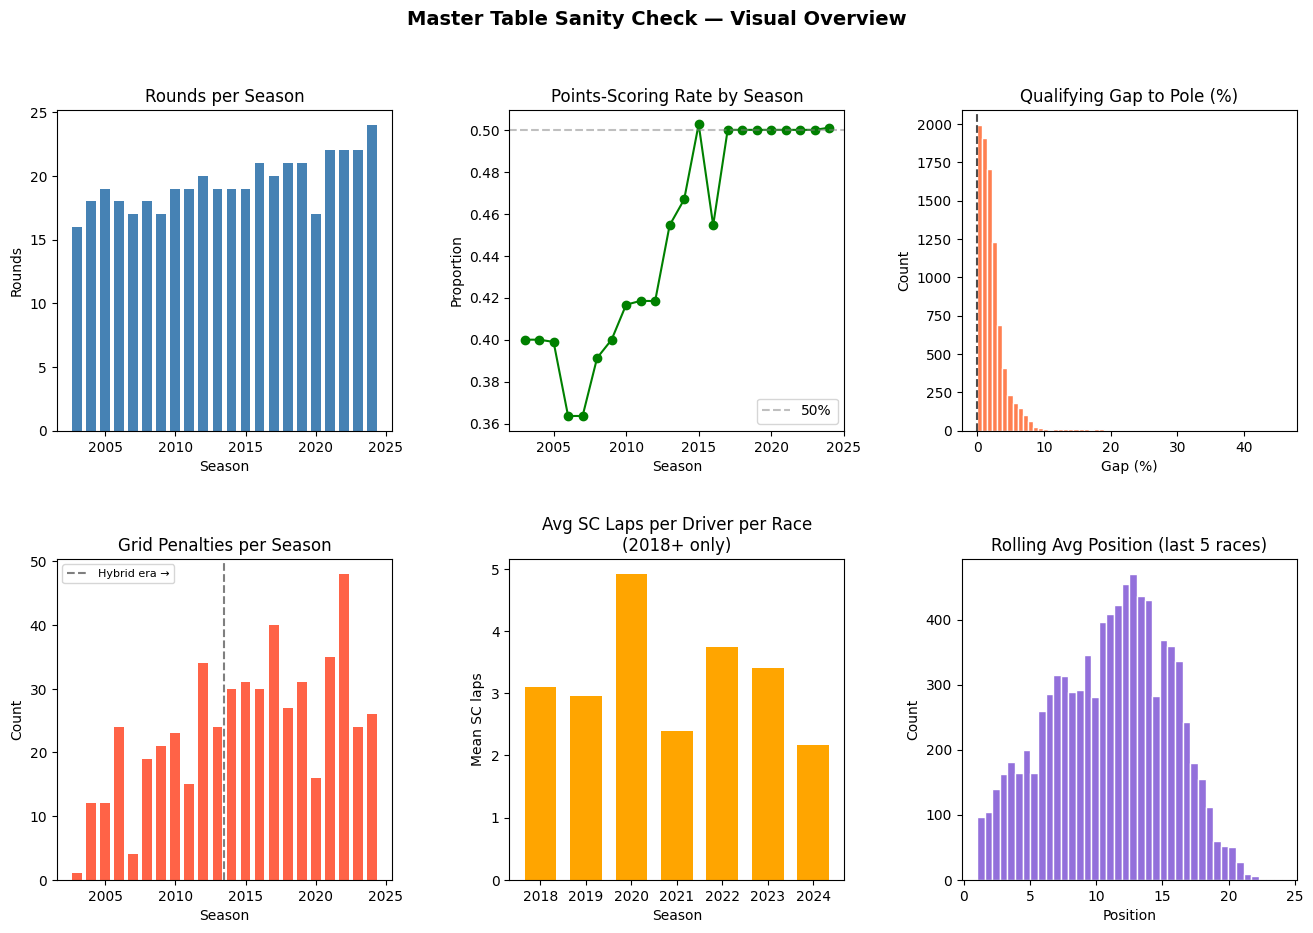

   ✓ Plots saved to Drive

SANITY CHECK COMPLETE


In [ ]:
# ── Master Table Sanity Checks ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

master = pd.read_csv("/content/drive/MyDrive/f1_data/master_driver_race.csv")

print("=" * 65)
print("MASTER TABLE SANITY CHECKS")
print("=" * 65)

# ── 1. Basic shape and types ──────────────────────────────────────────────────
print("\n1. SHAPE & DTYPES")
print(f"   Rows × Cols : {master.shape}")
print(f"   Seasons     : {sorted(master['season'].unique())}")
print(f"   Drivers     : {master['driverId'].nunique()} unique")
print(f"   Constructors: {master['constructorId'].nunique()} unique")
print(f"   Circuits    : {master['circuitId'].nunique()} unique")

# ── 2. No duplicate driver-race rows ─────────────────────────────────────────
print("\n2. DUPLICATE CHECK (each driver should appear once per race)")
dupes = master.duplicated(subset=["season", "round", "driverId"]).sum()
print(f"   Duplicate (season, round, driverId) rows: {dupes}")
print(f"   {'✓ PASS' if dupes == 0 else '✗ FAIL — investigate'}")

# ── 3. Drivers per race ───────────────────────────────────────────────────────
print("\n3. DRIVERS PER RACE (expect 18–26 per round)")
drivers_per_race = master.groupby(["season", "round"])["driverId"].count()
print(f"   Min  : {drivers_per_race.min()} "
      f"(season {drivers_per_race.idxmin()[0]} R{drivers_per_race.idxmin()[1]})")
print(f"   Max  : {drivers_per_race.max()} "
      f"(season {drivers_per_race.idxmax()[0]} R{drivers_per_race.idxmax()[1]})")
print(f"   Mean : {drivers_per_race.mean():.1f}")
unusual = drivers_per_race[drivers_per_race < 16]
if len(unusual) > 0:
    print(f"   ⚠ Races with <16 drivers: {unusual.to_dict()}")
else:
    print(f"   ✓ All races have ≥16 drivers")

# ── 4. scored_point consistency ───────────────────────────────────────────────
print("\n4. SCORED_POINT CONSISTENCY")
# Max 10 drivers should score per race (top 10 get points)
points_per_race = master.groupby(["season", "round"])["scored_point"].sum()
over_10 = points_per_race[points_per_race > 10]
print(f"   Races with >10 point-scorers: {len(over_10)}")
if len(over_10) > 0:
    print(f"   ⚠ {over_10.to_dict()}")
else:
    print(f"   ✓ Never more than 10 point-scorers per race")
print(f"   Overall base rate: {master['scored_point'].mean():.1%}")

# ── 5. quali_gap_pct sanity ───────────────────────────────────────────────────
print("\n5. QUALI_GAP_PCT (car quality proxy)")
gap = master["quali_gap_pct"].dropna()
print(f"   Min   : {gap.min():.4f}% (should be ~0 for pole sitter)")
print(f"   Median: {gap.median():.3f}%")
print(f"   Mean  : {gap.mean():.3f}%")
print(f"   P95   : {gap.quantile(0.95):.3f}%")
print(f"   Max   : {gap.max():.3f}%")
negative = (gap < -0.01).sum()
print(f"   Negative values: {negative} {'✓' if negative == 0 else '✗ INVESTIGATE'}")
# Pole sitter should have gap = 0 exactly
pole_rows = master[master["qualifyingPos"] == 1]["quali_gap_pct"].dropna()
print(f"   Pole sitter gap (should be ~0): mean={pole_rows.mean():.4f}%")

# ── 6. gridPenalty checks ─────────────────────────────────────────────────────
print("\n6. GRID PENALTY CHECKS")
penalties = master[master["gridPenalty"] == 1]
print(f"   Total penalties 2003–2024: {len(penalties)}")
print(f"   Per season avg: {len(penalties)/22:.1f}")
print(f"   Penalty places distribution:")
print(penalties["gridPenaltyPlaces"].value_counts().sort_index().to_string())
# Sanity: no penalty row should have 0 places
zero_place = (penalties["gridPenaltyPlaces"] == 0).sum()
print(f"   Rows with penalty=1 but 0 places: {zero_place} {'✓' if zero_place == 0 else '✗'}")

# ── 7. FastF1 feature coverage ────────────────────────────────────────────────
print("\n7. FASTF1 FEATURE COVERAGE (expect non-null only for 2018+)")
ff1_cols = ["underSC", "pitted_under_sc", "sc_laps_count", "compound", "startingCompound"]
ff1_available = [c for c in ff1_cols if c in master.columns]
for col in ff1_available:
    non_null = master[col].notna().sum()
    non_null_2018 = master[master["season"] >= 2018][col].notna().sum()
    rows_2018 = (master["season"] >= 2018).sum()
    print(f"   {col:<25}: {non_null:>5} non-null total | "
          f"{non_null_2018}/{rows_2018} in 2018+ "
          f"({non_null_2018/rows_2018*100:.1f}%)")

# ── 8. Rolling average leakage check ─────────────────────────────────────────
print("\n8. ROLLING AVG LEAKAGE CHECK (first race of career should be NaN)")
# Each driver's first ever race should have NaN rollingAvgPos5
first_races = master.sort_values(["season","round"]).groupby("driverId").first()
first_race_nulls = first_races["rollingAvgPos5"].isna().sum()
print(f"   Drivers with NaN on first race: {first_race_nulls}/{len(first_races)}")
print(f"   {'✓ PASS — no leakage' if first_race_nulls == len(first_races) else '✗ FAIL — possible leakage'}")

# ── 9. Weather coverage ───────────────────────────────────────────────────────
print("\n9. WEATHER COVERAGE")
print(f"   Rain races: {master.groupby(['season','round'])['rain_flag'].first().sum():.0f} "
      f"of {master.groupby(['season','round']).ngroups} total")
print(f"   Temp range: {master['avg_air_temp_c'].min():.1f}°C – "
      f"{master['avg_air_temp_c'].max():.1f}°C")
print(f"   Null weather rows: {master['avg_air_temp_c'].isna().sum()}")

# ── 10. Key driver-season spot checks ────────────────────────────────────────
print("\n10. SPOT CHECKS (known ground truth)")
checks = [
    # (season, driverId, expected_scored_point_rate_approx, description)
    (2023, "max_verstappen", 0.90, "Verstappen 2023 — dominated, should score ~95%"),
    (2020, "hamilton",       0.85, "Hamilton 2020 — won championship, should score ~90%"),
    (2019, "kubica",         0.05, "Kubica 2019 — struggled, should score rarely"),
]
for season, driver, expected_rate, desc in checks:
    rows = master[(master["season"] == season) & (master["driverId"] == driver)]
    if len(rows) == 0:
        print(f"   ⚠ {driver} {season} — not found in dataset")
        continue
    actual_rate = rows["scored_point"].mean()
    ok = abs(actual_rate - expected_rate) < 0.20
    print(f"   {desc}")
    print(f"     Races: {len(rows)} | Points rate: {actual_rate:.1%} | "
          f"{'✓ plausible' if ok else '⚠ check this'}")

# ── 11. Quick visual overview ─────────────────────────────────────────────────
print("\n11. GENERATING VISUAL OVERVIEW...")

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Master Table Sanity Check — Visual Overview", fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Plot 1: Races per season
ax1 = fig.add_subplot(gs[0, 0])
rounds_per_season = master.groupby("season")["round"].max()
ax1.bar(rounds_per_season.index, rounds_per_season.values, color="steelblue", width=0.7)
ax1.set_title("Rounds per Season")
ax1.set_xlabel("Season"); ax1.set_ylabel("Rounds")

# Plot 2: scored_point rate by season
ax2 = fig.add_subplot(gs[0, 1])
sp_by_season = master.groupby("season")["scored_point"].mean()
ax2.plot(sp_by_season.index, sp_by_season.values, marker="o", color="green")
ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="50%")
ax2.set_title("Points-Scoring Rate by Season")
ax2.set_xlabel("Season"); ax2.set_ylabel("Proportion"); ax2.legend()

# Plot 3: quali_gap_pct distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(master["quali_gap_pct"].dropna(), bins=60, color="coral", edgecolor="white")
ax3.set_title("Qualifying Gap to Pole (%)")
ax3.set_xlabel("Gap (%)"); ax3.set_ylabel("Count")
ax3.axvline(0, color="black", linestyle="--", alpha=0.7)

# Plot 4: grid penalties per season
ax4 = fig.add_subplot(gs[1, 0])
pen_by_season = master[master["gridPenalty"] == 1].groupby("season").size()
ax4.bar(pen_by_season.index, pen_by_season.values, color="tomato", width=0.7)
ax4.axvline(2013.5, color="black", linestyle="--", alpha=0.5, label="Hybrid era →")
ax4.set_title("Grid Penalties per Season")
ax4.set_xlabel("Season"); ax4.set_ylabel("Count"); ax4.legend(fontsize=8)

# Plot 5: SC laps coverage (FastF1 2018+)
ax5 = fig.add_subplot(gs[1, 1])
sc_by_season = master[master["season"] >= 2018].groupby("season")["sc_laps_count"].mean()
ax5.bar(sc_by_season.index, sc_by_season.values, color="orange", width=0.7)
ax5.set_title("Avg SC Laps per Driver per Race\n(2018+ only)")
ax5.set_xlabel("Season"); ax5.set_ylabel("Mean SC laps")

# Plot 6: rolling avg pos distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(master["rollingAvgPos5"].dropna(), bins=40, color="mediumpurple", edgecolor="white")
ax6.set_title("Rolling Avg Position (last 5 races)")
ax6.set_xlabel("Position"); ax6.set_ylabel("Count")

plt.savefig("/content/drive/MyDrive/f1_data/sanity_check_plots.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("   ✓ Plots saved to Drive")

print("\n" + "=" * 65)
print("SANITY CHECK COMPLETE")
print("=" * 65)

In [ ]:
import pandas as pd
import numpy as np

master = pd.read_csv("/content/drive/MyDrive/f1_data/master_driver_race.csv")
master = master.sort_values(["season", "round"]).reset_index(drop=True)

first_races = master.groupby("driverId").first().reset_index()
leakers = first_races[first_races["rollingAvgPos5"].notna()][
    ["driverId", "season", "round", "rollingAvgPos5"]
].sort_values("season")

print(f"Drivers with non-null rollingAvgPos5 on first race: {len(leakers)}")
print(leakers.to_string(index=False))

Drivers with non-null rollingAvgPos5 on first race: 109
          driverId  season  round  rollingAvgPos5
            alonso    2003      1             7.0
       baumgartner    2003     13            16.0
       barrichello    2003      1            20.0
            button    2003      1            10.0
            firman    2003      1            19.0
        fisichella    2003      1            12.0
          frentzen    2003      1             6.0
         coulthard    2003      1             1.0
              gene    2003     14             5.0
             matta    2003      1            18.0
             kiesa    2003     12            12.0
          heidfeld    2003      1            15.0
michael_schumacher    2003      1             4.0
         raikkonen    2003      1             3.0
             panis    2003      1            14.0
           montoya    2003      1             2.0
        verstappen    2003      1            11.0
   ralf_schumacher    2003      1           

In [ ]:
import pandas as pd
import numpy as np

master = pd.read_csv("/content/drive/MyDrive/f1_data/master_driver_race.csv")
drivers_df = pd.read_csv("/content/drive/MyDrive/f1_data/drivers.csv")
master = master.sort_values(["season", "round"]).reset_index(drop=True)

# Get each driver's first appearance in our dataset
first_in_dataset = master.groupby("driverId")[["season","round"]].first().reset_index()
first_in_dataset.columns = ["driverId", "first_season", "first_round"]

# A genuine rookie is a driver whose first season in our dataset
# is also the first season they ever raced in F1
# Proxy: if their first appearance in our data is 2003 R1 or later
# AND they have no pre-2003 history, their rolling avg should be NaN
# We can't know pre-2003 history from our data alone, so instead:
# Check drivers whose first_season > 2003 — these are definitive rookies
# (anyone starting 2004+ cannot have pre-2003 experience in our window)

definitive_rookies = first_in_dataset[first_in_dataset["first_season"] > 2003]

print(f"Drivers with first appearance after 2003: {len(definitive_rookies)}")
print(f"(These are definitive rookies — their rolling avg MUST be NaN on debut)\n")

leakage_found = False
for _, row in definitive_rookies.iterrows():
    driver = row["driverId"]
    s, r   = row["first_season"], row["first_round"]
    debut_row = master[
        (master["driverId"] == driver) &
        (master["season"]   == s) &
        (master["round"]    == r)
    ]
    rolling_val = debut_row["rollingAvgPos5"].values[0]
    if not pd.isna(rolling_val):
        print(f"  ✗ LEAK: {driver} debut {s} R{r} has rollingAvgPos5={rolling_val}")
        leakage_found = True

if not leakage_found:
    print("✓ PASS — No leakage detected for any post-2003 debut driver")
    print("  (Pre-2003 drivers showing non-null values is expected —")
    print("   they had racing history before our dataset window begins)")

Drivers with first appearance after 2003: 89
(These are definitive rookies — their rolling avg MUST be NaN on debut)

✓ PASS — No leakage detected for any post-2003 debut driver
  (Pre-2003 drivers showing non-null values is expected —
   they had racing history before our dataset window begins)


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

DRIVE_DIR = Path("/content/drive/MyDrive/f1_data")

print("=" * 65)
print("FULL DATA INVENTORY — F1 Strategic Decision-Making Study")
print("=" * 65)

# ── 1. File-level overview ────────────────────────────────────────────────────
print("\n1. FILES ON DRIVE")
print(f"{'File':<45} {'Rows':>8} {'Cols':>6} {'Size (KB)':>10}")
print("-" * 75)

file_specs = {
    "circuits.csv"                  : "static reference",
    "drivers.csv"                   : "static reference",
    "constructors.csv"              : "static reference",
    "race_results.csv"              : "2003-2024",
    "qualifying.csv"                : "2003-2024",
    "driver_standings.csv"          : "2002-2024",
    "constructor_standings.csv"     : "2002-2024",
    "prev_constructor_standings.csv": "2002-2024 shifted",
    "pitstops.csv"                  : "2012-2024",
    "pitstop_counts.csv"            : "2012-2024",
    "ergast_lap_aggregates.csv"     : "2011-2017",
    "weather.csv"                   : "2003-2024",
    "fastf1_laps.csv"               : "2018-2024",
    "fastf1_race_control.csv"       : "2018-2024",
    "master_driver_race.csv"        : "2003-2024 master",
}

loaded = {}
for fname, scope in file_specs.items():
    path = DRIVE_DIR / fname
    if path.exists() and path.stat().st_size > 0:
        try:
            df = pd.read_csv(path, low_memory=False)
            loaded[fname] = df
            kb = path.stat().st_size / 1024
            print(f"  {fname:<43} {len(df):>8,} {len(df.columns):>6} {kb:>10.1f}")
        except Exception as e:
            print(f"  {fname:<43} ERROR: {e}")
    else:
        print(f"  {fname:<43} {'MISSING':>8}")

# ── 2. FastF1 coverage detail ─────────────────────────────────────────────────
print("\n2. FASTF1 LAP DATA — SEASON AND ROUND COVERAGE")
if "fastf1_laps.csv" in loaded:
    ff1 = loaded["fastf1_laps.csv"]
    coverage = ff1.groupby("season")["round"].nunique()
    total_laps = ff1.groupby("season")["lap_number"].count()
    sc_laps = ff1.groupby("season")["underSC"].sum()
    print(f"  {'Season':<8} {'Rounds':>8} {'Total Laps':>12} {'SC Laps':>10}")
    print(f"  {'-'*42}")
    for season in sorted(ff1["season"].unique()):
        print(f"  {season:<8} {coverage[season]:>8} "
              f"{total_laps[season]:>12,} {int(sc_laps[season]):>10,}")
    print(f"  {'-'*42}")
    print(f"  {'TOTAL':<8} {coverage.sum():>8} "
          f"{total_laps.sum():>12,} {int(sc_laps.sum()):>10,}")

    # Which rounds per season
    print(f"\n  Rounds collected per season:")
    for season in sorted(ff1["season"].unique()):
        rounds = sorted(ff1[ff1["season"] == season]["round"].unique())
        print(f"    {season}: {rounds}")

# ── 3. FastF1 race control coverage ──────────────────────────────────────────
print("\n3. FASTF1 RACE CONTROL MESSAGES — COVERAGE")
if "fastf1_race_control.csv" in loaded:
    rc = loaded["fastf1_race_control.csv"]
    print(f"  Total messages: {len(rc):,}")
    if "season" in rc.columns:
        print(f"  By season:")
        print(rc.groupby("season").size().to_string())
    if "Category" in rc.columns:
        print(f"\n  Message categories:")
        print(rc["Category"].value_counts().to_string())

# ── 4. Master table cross-validation ─────────────────────────────────────────
print("\n4. MASTER TABLE CROSS-VALIDATION")
if "master_driver_race.csv" in loaded and "race_results.csv" in loaded:
    master = loaded["master_driver_race.csv"]
    results = loaded["race_results.csv"]

    print(f"  master_driver_race rows : {len(master):,}")
    print(f"  race_results rows       : {len(results):,}")
    print(f"  Row count match         : {'✓' if len(master) == len(results) else '✗ MISMATCH'}")

    # Season coverage match
    master_seasons = set(master["season"].unique())
    results_seasons = set(results["season"].unique())
    print(f"  Seasons in master       : {sorted(master_seasons)}")
    print(f"  Seasons match           : {'✓' if master_seasons == results_seasons else '✗'}")

    # FastF1 join rate in master
    if "pitted_under_sc" in master.columns:
        ff1_rows = master[master["season"] >= 2018]
        join_rate = ff1_rows["pitted_under_sc"].notna().mean()
        print(f"\n  FastF1 join rate (2018+ rows): {join_rate:.1%}")
        print(f"  2018+ rows in master         : {len(ff1_rows):,}")
        by_season = ff1_rows.groupby("season")["pitted_under_sc"].apply(
            lambda x: x.notna().mean()
        )
        print(f"  Join rate by season (2018+):")
        for s, r in by_season.items():
            print(f"    {s}: {r:.1%}")

# ── 5. Pit stop coverage ──────────────────────────────────────────────────────
print("\n5. PIT STOP RECORDS — COVERAGE")
if "pitstops.csv" in loaded:
    ps = loaded["pitstops.csv"]
    print(f"  Total pit stops: {len(ps):,}")
    print(f"  By season:")
    print(ps.groupby("season").size().to_string())
    print(f"\n  Avg stops per driver per race: "
          f"{ps.groupby(['season','round','driverId']).size().mean():.2f}")
    print(f"  Repair stops flagged (>120s): {ps['repair_stop_flag'].sum()}")

# ── 6. Weather coverage ───────────────────────────────────────────────────────
print("\n6. WEATHER COVERAGE")
if "weather.csv" in loaded:
    w = loaded["weather.csv"]
    print(f"  Total race-weekend records : {len(w):,}")
    print(f"  Seasons covered            : {sorted(w['season'].unique())}")
    print(f"  Rain races (flag=1)        : {w['rain_flag'].sum():.0f}")
    print(f"  Data available             : {w['data_available'].sum()}/{len(w)}")
    print(f"  Temp range                 : "
          f"{w['avg_air_temp_c'].min():.1f}°C to {w['avg_air_temp_c'].max():.1f}°C")

# ── 7. Ergast lap aggregates ──────────────────────────────────────────────────
print("\n7. ERGAST LAP AGGREGATES — COVERAGE (2011-2017)")
if "ergast_lap_aggregates.csv" in loaded:
    el = loaded["ergast_lap_aggregates.csv"]
    print(f"  Total rows : {len(el):,}")
    print(f"  By season  :")
    print(el.groupby("season").size().to_string())

print("\n" + "=" * 65)
print("INVENTORY COMPLETE — paste output for review")
print("=" * 65)

FULL DATA INVENTORY — F1 Strategic Decision-Making Study

1. FILES ON DRIVE
File                                              Rows   Cols  Size (KB)
---------------------------------------------------------------------------
  circuits.csv                                      78      7        8.8
  drivers.csv                                      879      8       76.4
  constructors.csv                                 214      4       14.9
  race_results.csv                               8,966     17      883.3
  qualifying.csv                                 8,946     19     1146.1
  driver_standings.csv                             549      6       16.9
  constructor_standings.csv                        244      5        5.5
  prev_constructor_standings.csv                   244      5        6.2
  pitstops.csv                                  10,256     11      664.5
  pitstop_counts.csv                             5,146      4       90.6
  ergast_lap_aggregates.csv                  

In [ ]:
from pathlib import Path
import pandas as pd

DRIVE_DIR = Path("/content/drive/MyDrive/f1_data")

print("ALL FILES AND FOLDERS IN f1_data/")
print("=" * 65)

# Top-level files
print("\nTOP-LEVEL FILES:")
all_files = sorted([f for f in DRIVE_DIR.iterdir() if f.is_file()])
for f in all_files:
    kb = f.stat().st_size / 1024
    print(f"  {f.name:<50} {kb:>8.1f} KB")

# Subfolders and their contents
print("\nSUBFOLDERS:")
all_dirs = sorted([d for d in DRIVE_DIR.iterdir() if d.is_dir()])
if not all_dirs:
    print("  None found")
for d in all_dirs:
    files_in_dir = sorted(d.glob("*"))
    total_kb = sum(f.stat().st_size for f in files_in_dir if f.is_file()) / 1024
    print(f"\n  {d.name}/ ({len(files_in_dir)} files, {total_kb:.0f} KB total)")
    for f in files_in_dir[:10]:  # show first 10
        kb = f.stat().st_size / 1024
        print(f"    {f.name:<48} {kb:>8.1f} KB")
    if len(files_in_dir) > 10:
        print(f"    ... and {len(files_in_dir) - 10} more files")

ALL FILES AND FOLDERS IN f1_data/

TOP-LEVEL FILES:
  circuits.csv                                            8.8 KB
  code_to_driverid.json                                   2.0 KB
  constructor_standings.csv                               5.5 KB
  constructors.csv                                       14.9 KB
  data_quality_report.txt                                 3.3 KB
  driver_standings.csv                                   16.9 KB
  drivers.csv                                            76.4 KB
  ergast_circuits.csv                                     8.8 KB
  ergast_constructor_standings.csv                        5.3 KB
  ergast_constructors.csv                                 5.4 KB
  ergast_driver_standings.csv                            12.4 KB
  ergast_drivers.csv                                     38.2 KB
  ergast_lap_aggregates.csv                             226.3 KB
  ergast_lap_times_aggregate.csv                          9.7 KB
  ergast_laps_checkpoint.csv          

In [ ]:
from pathlib import Path

DRIVE_DIR = Path("/content/drive/MyDrive/f1_data")

to_delete = [
    # Old pipeline duplicates (ergast_ prefix)
    "ergast_circuits.csv",
    "ergast_constructors.csv",
    "ergast_drivers.csv",
    "ergast_driver_standings.csv",
    "ergast_constructor_standings.csv",
    "ergast_pit_stops.csv",
    "ergast_qualifying.csv",
    "ergast_race_results.csv",
    "ergast_lap_times_aggregate.csv",
    "ergast_laps_checkpoint.csv",
    # Intermediate upload artefacts
    "fastf1_laps_2018_2021.csv",
    "fastf1_rc_2018_2021.csv",
    "ff1_parts.zip",
    # Old pipeline weather duplicate
    "weather_race_day.csv",
]

print("Files to delete:")
total_kb = 0
for fname in to_delete:
    path = DRIVE_DIR / fname
    if path.exists():
        kb = path.stat().st_size / 1024
        total_kb += kb
        print(f"  {fname:<50} {kb:>8.1f} KB")
    else:
        print(f"  {fname:<50} NOT FOUND (already gone)")

print(f"\nTotal space to recover: {total_kb/1024:.1f} MB")
print("\nConfirm deletion? Run the block below.")

Files to delete:
  ergast_circuits.csv                                     8.8 KB
  ergast_constructors.csv                                 5.4 KB
  ergast_drivers.csv                                     38.2 KB
  ergast_driver_standings.csv                            12.4 KB
  ergast_constructor_standings.csv                        5.3 KB
  ergast_pit_stops.csv                                  866.0 KB
  ergast_qualifying.csv                                 851.4 KB
  ergast_race_results.csv                              1100.0 KB
  ergast_lap_times_aggregate.csv                          9.7 KB
  ergast_laps_checkpoint.csv                              0.1 KB
  fastf1_laps_2018_2021.csv                            9006.9 KB
  fastf1_rc_2018_2021.csv                               787.6 KB
  ff1_parts.zip                                        1573.7 KB
  weather_race_day.csv                                   28.8 KB

Total space to recover: 14.0 MB

Confirm deletion? Run the block below.


In [ ]:
deleted = []
not_found = []

for fname in to_delete:
    path = DRIVE_DIR / fname
    if path.exists():
        path.unlink()
        deleted.append(fname)
    else:
        not_found.append(fname)

print(f"✓ Deleted {len(deleted)} files")
for f in deleted:
    print(f"  {f}")
if not_found:
    print(f"\nNot found (already gone): {not_found}")

# Verify canonical files are still intact
canonical = [
    "race_results.csv", "qualifying.csv", "pitstops.csv",
    "fastf1_laps.csv", "fastf1_race_control.csv",
    "master_driver_race.csv", "weather.csv",
    "ergast_lap_aggregates.csv", "ff1_checkpoint.csv",
]
print(f"\nCanonical files still present:")
for f in canonical:
    path = DRIVE_DIR / f
    exists = path.exists()
    kb = path.stat().st_size / 1024 if exists else 0
    print(f"  {'✓' if exists else '✗'} {f:<45} {kb:>8.1f} KB")

✓ Deleted 14 files
  ergast_circuits.csv
  ergast_constructors.csv
  ergast_drivers.csv
  ergast_driver_standings.csv
  ergast_constructor_standings.csv
  ergast_pit_stops.csv
  ergast_qualifying.csv
  ergast_race_results.csv
  ergast_lap_times_aggregate.csv
  ergast_laps_checkpoint.csv
  fastf1_laps_2018_2021.csv
  fastf1_rc_2018_2021.csv
  ff1_parts.zip
  weather_race_day.csv

Canonical files still present:
  ✓ race_results.csv                                 883.3 KB
  ✓ qualifying.csv                                  1146.1 KB
  ✓ pitstops.csv                                     664.5 KB
  ✓ fastf1_laps.csv                                14427.2 KB
  ✓ fastf1_race_control.csv                          524.6 KB
  ✓ master_driver_race.csv                          2415.9 KB
  ✓ weather.csv                                       26.5 KB
  ✓ ergast_lap_aggregates.csv                        226.3 KB
  ✓ ff1_checkpoint.csv                                 7.4 KB


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

DRIVE_DIR = Path("/content/drive/MyDrive/f1_data")
master = pd.read_csv(DRIVE_DIR / "master_driver_race.csv")

print("=" * 65)
print("FINAL MASTER TABLE SANITY CHECK")
print("=" * 65)

# ── 1. Shape ──────────────────────────────────────────────────────────────────
print(f"\n1. SHAPE")
print(f"   Rows × Cols : {master.shape}")
print(f"   Seasons     : {master['season'].min()}–{master['season'].max()}")
print(f"   Drivers     : {master['driverId'].nunique()}")
print(f"   Constructors: {master['constructorId'].nunique()}")
print(f"   Circuits    : {master['circuitId'].nunique()}")

# ── 2. Primary target variable ────────────────────────────────────────────────
print(f"\n2. TARGET VARIABLE — scored_point")
print(f"   Null rate   : {master['scored_point'].isna().mean():.1%}  (must be 0%)")
print(f"   Values      : {master['scored_point'].value_counts().to_dict()}")
print(f"   Base rate   : {master['scored_point'].mean():.1%}")
sp_per_race = master.groupby(["season","round"])["scored_point"].sum()
print(f"   Max scorers per race: {sp_per_race.max()} (must be ≤10)")
print(f"   Min scorers per race: {sp_per_race.min()}")

# ── 3. Block 1 inputs (unsupervised — circuit features) ───────────────────────
print(f"\n3. BLOCK 1 INPUTS — Circuit features")
b1_cols = {
    "grid_to_pos"    : "Overtaking index base",
    "qualifyingPos"  : "Track position dominance base",
    "totalPitStops"  : "Strategic spread base (2012+)",
    "quali_gap_pct"  : "Pace spread base",
    "circuitId"      : "Join key",
}
for col, desc in b1_cols.items():
    null_rate = master[col].isna().mean()
    flag = "✓" if null_rate < 0.50 else "⚠ HIGH"
    print(f"   {col:<20}: {null_rate:>6.1%} null  {flag}  — {desc}")

# ── 4. Block 2 inputs (causal A — SC IV) ─────────────────────────────────────
print(f"\n4. BLOCK 2 INPUTS — Safety Car IV (2018+ only)")
b2_sample = master[master["season"] >= 2018].copy()
b2_cols = {
    "pitted_under_sc"            : "Treatment",
    "sc_laps_count"              : "Instrument proxy",
    "quali_gap_pct"              : "Car quality confounder",
    "constructor_quality_quintile": "Car quality moderator",
    "scored_point"               : "Outcome",
}
print(f"   2018+ rows: {len(b2_sample):,}")
for col, role in b2_cols.items():
    null_rate = b2_sample[col].isna().mean()
    flag = "✓" if null_rate < 0.20 else "⚠ CHECK"
    print(f"   {col:<30}: {null_rate:>6.1%} null  {flag}  — {role}")

# SC events summary
if "pitted_under_sc" in master.columns:
    sc_sample = master[master["pitted_under_sc"].notna()]
    pitted = (sc_sample["pitted_under_sc"] == 1).sum()
    print(f"\n   Driver-races with FastF1 data : {len(sc_sample):,}")
    print(f"   Of which pitted under SC      : {pitted:,} ({pitted/len(sc_sample):.1%})")

# ── 5. Block 3 inputs (causal B — penalty timing) ────────────────────────────
print(f"\n5. BLOCK 3 INPUTS — Grid Penalty Timing (2003–2024)")
penalty_sample = master[master["gridPenalty"] == 1]
print(f"   Total penalty events     : {len(penalty_sample):,}")
print(f"   Seasons with penalties   : {sorted(penalty_sample['season'].unique())}")
print(f"   Pre-2014 penalties       : {(penalty_sample['season'] < 2014).sum()}")
print(f"   Post-2014 penalties      : {(penalty_sample['season'] >= 2014).sum()}")
print(f"   Avg penalty places       : {penalty_sample['gridPenaltyPlaces'].mean():.1f}")
b3_cols = {
    "gridPenalty"               : "Treatment indicator",
    "gridPenaltyPlaces"         : "Treatment magnitude",
    "quali_gap_pct"             : "Car quality confounder",
    "constructor_quality_quintile": "Sophistication moderator",
    "positionOrder"             : "Outcome (continuous)",
    "scored_point"              : "Outcome (binary)",
    "circuitId"                 : "For elasticity join",
}
for col, role in b3_cols.items():
    null_rate = master[col].isna().mean()
    flag = "✓" if null_rate < 0.10 else "⚠ CHECK"
    print(f"   {col:<30}: {null_rate:>6.1%} null  {flag}  — {role}")

# ── 6. Block 4 inputs (supervised — feature groups) ──────────────────────────
print(f"\n6. BLOCK 4 INPUTS — Supervised Learning Feature Groups")

group1 = {
    "quali_gap_pct"              : "G1 — Car quality",
    "grid"                       : "G1 — Starting position",
    "prevSeasonConstructorPos"   : "G1 — Prev season constructor",
    "rollingAvgPos5"             : "G1 — Rolling avg position",
}
group2 = {
    "gridPenalty"                : "G2 — Strategic context",
    "rain_flag"                  : "G2 — Weather",
    "avg_air_temp_c"             : "G2 — Temperature",
}
group3 = {
    "pitted_under_sc"            : "G3 — SC behaviour (2018+)",
    "totalPitStops"              : "G3 — Pit strategy (2012+)",
    "startingCompound"           : "G3 — Tyre strategy (2018+)",
}

for group, cols in [("GROUP 1 — Car Quality", group1),
                     ("GROUP 2 — Strategic Context", group2),
                     ("GROUP 3 — Strategic Behaviour", group3)]:
    print(f"\n   {group}")
    for col, desc in cols.items():
        null_rate = master[col].isna().mean() if col in master.columns else 1.0
        present = col in master.columns
        flag = "✓" if present and null_rate < 0.50 else ("⚠ HIGH NULL" if present else "✗ MISSING")
        print(f"     {col:<30}: {null_rate:>6.1%} null  {flag}")

# ── 7. Walk-forward validation viability ──────────────────────────────────────
print(f"\n7. WALK-FORWARD VALIDATION — Rows per season")
print(f"   (train on years ≤ t, test on year t+1)")
rows_per_season = master.groupby("season").size()
for season, n in rows_per_season.items():
    cumulative = master[master["season"] <= season].shape[0]
    print(f"   {season}: {n:>4} rows  |  cumulative train set: {cumulative:>5}")

# ── 8. Key variable distributions ────────────────────────────────────────────
print(f"\n8. KEY DISTRIBUTIONS")
print(f"   quali_gap_pct  — mean: {master['quali_gap_pct'].mean():.3f}%  "
      f"std: {master['quali_gap_pct'].std():.3f}%  "
      f"max: {master['quali_gap_pct'].max():.3f}%")
print(f"   gridPenaltyPlaces (when >0) — "
      f"mean: {master[master['gridPenaltyPlaces']>0]['gridPenaltyPlaces'].mean():.1f}  "
      f"max: {master[master['gridPenaltyPlaces']>0]['gridPenaltyPlaces'].max():.0f}")
print(f"   rollingAvgPos5 — mean: {master['rollingAvgPos5'].mean():.1f}  "
      f"std: {master['rollingAvgPos5'].std():.1f}")
print(f"   rain_flag      — {master['rain_flag'].mean():.1%} of races")
print(f"   scored_point   — {master['scored_point'].mean():.1%} base rate")

print(f"\n{'=' * 65}")
print(f"FINAL SANITY CHECK COMPLETE")
print(f"{'=' * 65}")

FINAL MASTER TABLE SANITY CHECK

1. SHAPE
   Rows × Cols : (8966, 48)
   Seasons     : 2003–2024
   Drivers     : 113
   Constructors: 35
   Circuits    : 38

2. TARGET VARIABLE — scored_point
   Null rate   : 0.0%  (must be 0%)
   Values      : {0: 4934, 1: 4032}
   Base rate   : 45.0%
   Max scorers per race: 10 (must be ≤10)
   Min scorers per race: 6

3. BLOCK 1 INPUTS — Circuit features
   grid_to_pos         :   0.6% null  ✓  — Overtaking index base
   qualifyingPos       :   0.3% null  ✓  — Track position dominance base
   totalPitStops       :  42.6% null  ✓  — Strategic spread base (2012+)
   quali_gap_pct       :   1.6% null  ✓  — Pace spread base
   circuitId           :   0.0% null  ✓  — Join key

4. BLOCK 2 INPUTS — Safety Car IV (2018+ only)
   2018+ rows: 2,979
   pitted_under_sc               :  13.8% null  ✓  — Treatment
   sc_laps_count                 :  13.8% null  ✓  — Instrument proxy
   quali_gap_pct                 :   1.2% null  ✓  — Car quality confounder
   c